# Libraries and Data Information

## Installations

In [1]:
!pip install tensorflow==2.13.0
!pip install spikingjelly
!pip install keras_spiking --upgrade
!pip install statsmodels

ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 16.4 MB/s eta 0:00:00


Installing Nengo-Dl requires a workaround as shown in the following [link](https://forum.nengo.ai/t/import-nengodl-in-google-colab/1321).

In [2]:
# Installing nengo-dl on Google Colab
#!git clone https://github.com/nengo/nengo_dl.git
#!pip install --upgrade keras

In [3]:
# !pip show tensorflow nengo-dl

In [4]:
#!pip install tensorflow==2.11

In [5]:
#!pip show tensorflow

## Libraries

In [6]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as scatter
import matplotlib.cm as cm


from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

# keras/tensorflow imports
import tensorflow as tf, gc
from keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Flatten, Conv1D
from keras.layers import MaxPooling1D
from keras.models import Sequential
import keras_spiking
import keras
import scipy


# warnings imports
import warnings
warnings.filterwarnings("ignore")

# torch imports
import torch
import torch.nn as nn
from torchvision import transforms
#device = "cuda" if torch.cuda.is_available() else "cpu"
#print(f"{device}" " is available.")

# Determine available TensorFlow device
tf_gpus = tf.config.list_physical_devices('GPU')
tf_tpus = tf.config.list_physical_devices('TPU')

if tf_gpus:
    tf_device_name = "GPU"
    # Ensure TensorFlow uses the GPU
    tf.config.set_visible_devices(tf_gpus, 'GPU')
    print("GPU is available and configured for TensorFlow.")
    # Optionally enable mixed precision for performance on compatible GPUs
    # This might require careful tuning for stability
    # try:
    #     policy = tf.keras.mixed_precision.Policy('mixed_float16')
    #     tf.keras.mixed_precision.set_global_policy(policy)
    #     print("Mixed precision training enabled.")
    # except Exception as e:
    #     print(f"Could not enable mixed precision: {e}")
elif tf_tpus:
    tf_device_name = "TPU"
    # TPU setup requires tf.distribute.TPUStrategy, which changes model definition and compilation.
    # For this simple change, we'll just acknowledge its presence.
    print("TPU is available for TensorFlow, but requires tf.distribute.TPUStrategy for full utilization.")
    print("Training will proceed on CPU unless TPUStrategy is explicitly implemented for each model.")
else:
    tf_device_name = "CPU"
    print("No GPU or TPU available. Training will use CPU.")

device = tf_device_name # Use this global 'device' for conditional logic in training
print(f"TensorFlow will attempt to use {device}.")


# spikingjelly imports
from spikingjelly.clock_driven import neuron, surrogate
#from spikingjelly.clock_driven import accelerating
import spikingjelly.clock_driven.neuron as sj


# Other imports
from urllib.request import urlretrieve
import collections
import numpy as np
import pandas as pd
from math import sqrt
import os
import pickle
from datetime import datetime, timedelta
from google.colab import drive
import time, random
import statsmodels
from statsmodels.stats.api import DescrStatsW


# Clear Backend
import gc
tf.keras.backend.clear_session()
gc.collect()

No GPU or TPU available. Training will use CPU.
TensorFlow will attempt to use CPU.


0

# Load Data

In [7]:
from google.colab import files, runtime
data_to_load = files.upload()

Saving AEP_hourly_sorted.csv to AEP_hourly_sorted.csv


# Read and Check Data

## Preprocessing stage.

In [8]:
filename_list = list(data_to_load.keys())
filename = filename_list[0]

In [9]:
df_entire = pd.read_csv(filename)
df_entire.head()

,Datetime,AEP_MW
0,10/1/2004 1:00,12379
1,10/1/2004 2:00,11935
2,10/1/2004 3:00,11692
3,10/1/2004 4:00,11597
4,10/1/2004 5:00,11681


In [10]:
df_entire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Datetime  121273 non-null  object
 1   AEP_MW    121273 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


In [11]:
title_name = 'Hourly Energy Consumption from 2004/12/31 to 2018/01/02'

## Other Pre-Processing Information

In [12]:
# We must convert the Datetime column to Datetime format
df_entire['Datetime'] = pd.to_datetime(df_entire['Datetime'])

# We index the Datetime column after transformation
df_entire.set_index('Datetime', inplace=True)
df_entire.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379
2004-10-01 02:00:00,11935
2004-10-01 03:00:00,11692
2004-10-01 04:00:00,11597
2004-10-01 05:00:00,11681


In [13]:
# checking missing data
df_entire.isna().sum()

,0
AEP_MW,0


In [14]:
# Let's look at the years in the data set
years = df_entire.index.year.unique()
years

Index([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018],
      dtype='int32', name='Datetime')

## Plot Hourly Energy Consumption (AEP_MW) based on Trends and Seasonality.

In [15]:
def plot_aep_hr(select_df, start, end, seasonality, title_name, feature):
    plt.figure(figsize=(16, 16))
    plt.plot(select_df[start:end], label=feature)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.ylabel(feature, fontsize = 20)
    plt.xlabel("Date", fontsize = 20)
    plt.title("{0} ({1})".format(title_name, seasonality),
              fontsize = 20)
    plt.show()

### Trend Plot

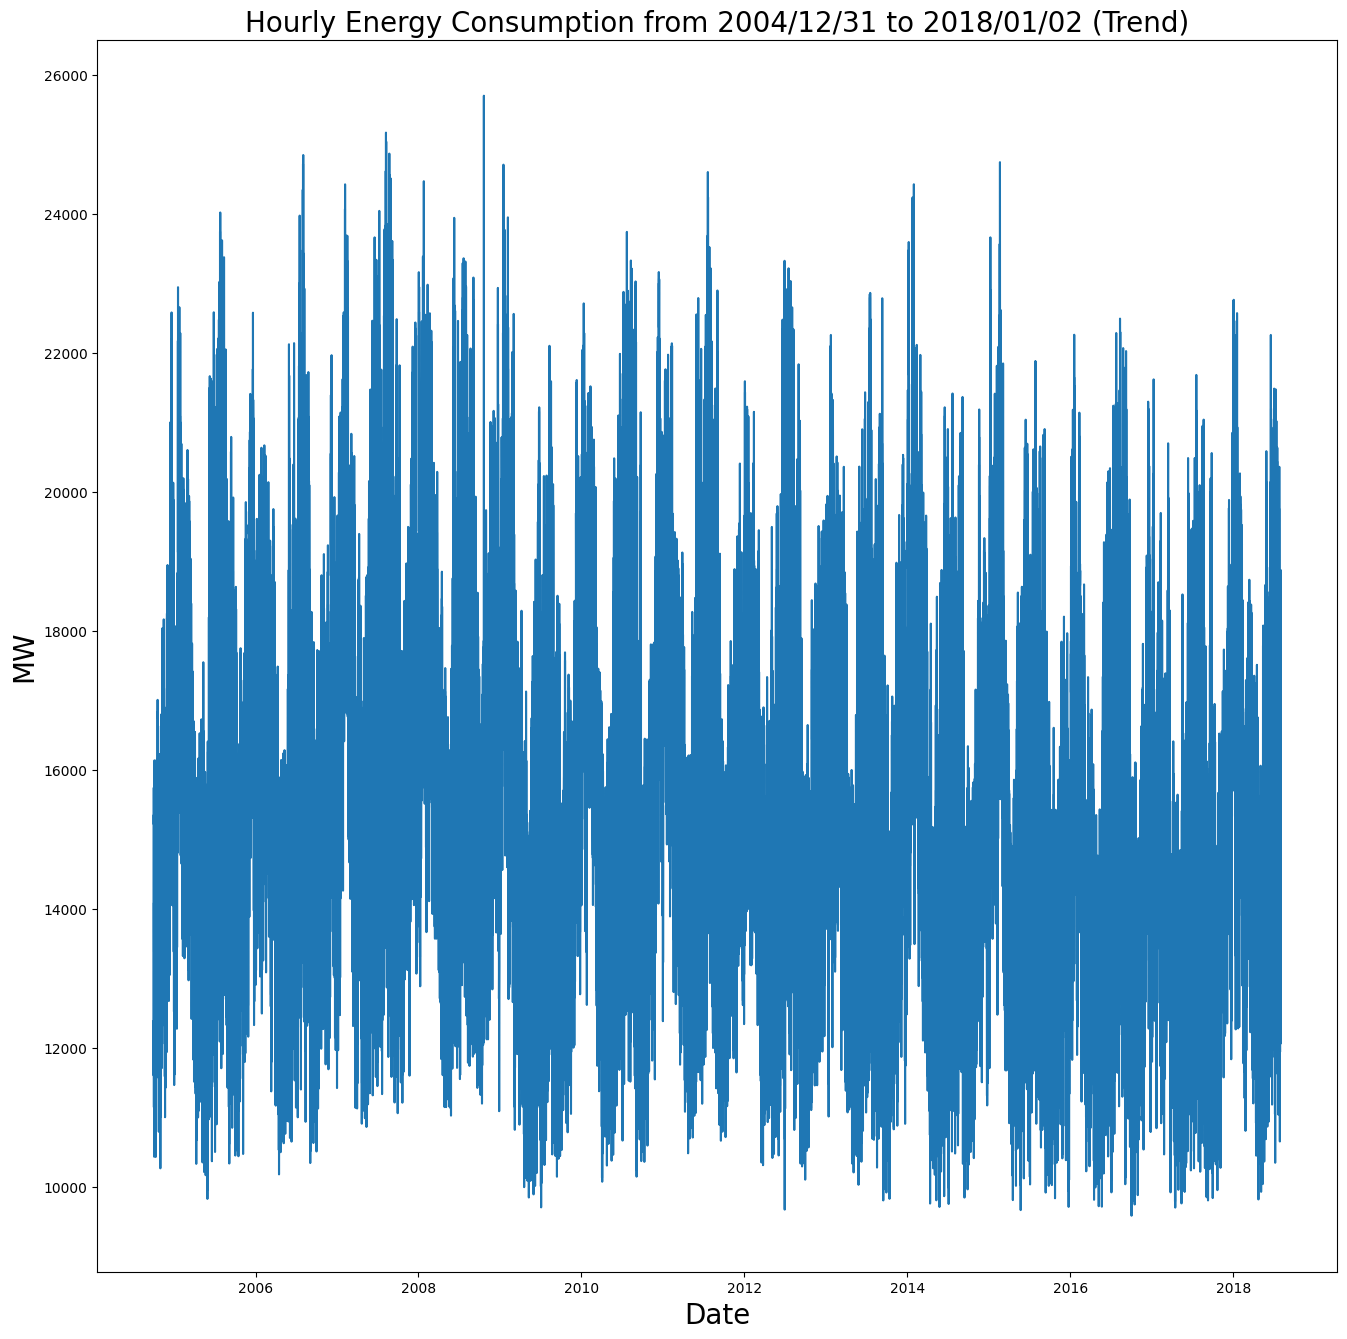

In [16]:
plot_aep_hr(df_entire, 0, df_entire.shape[0]-1, "Trend",
            title_name, 'MW')

### Yearly Plots (Seasonality)

In [17]:
yearly_df = df_entire.query("Datetime >= '2008-01-01' \
                       and Datetime <= '2009-01-01'")
yearly_df

,AEP_MW
Datetime,
2008-01-01 00:00:00,15411
2008-01-01 01:00:00,14755
2008-01-01 02:00:00,14475
2008-01-01 03:00:00,14217
2008-01-01 04:00:00,14149
...,...
2008-12-31 20:00:00,18670
2008-12-31 21:00:00,18319
2008-12-31 22:00:00,17963


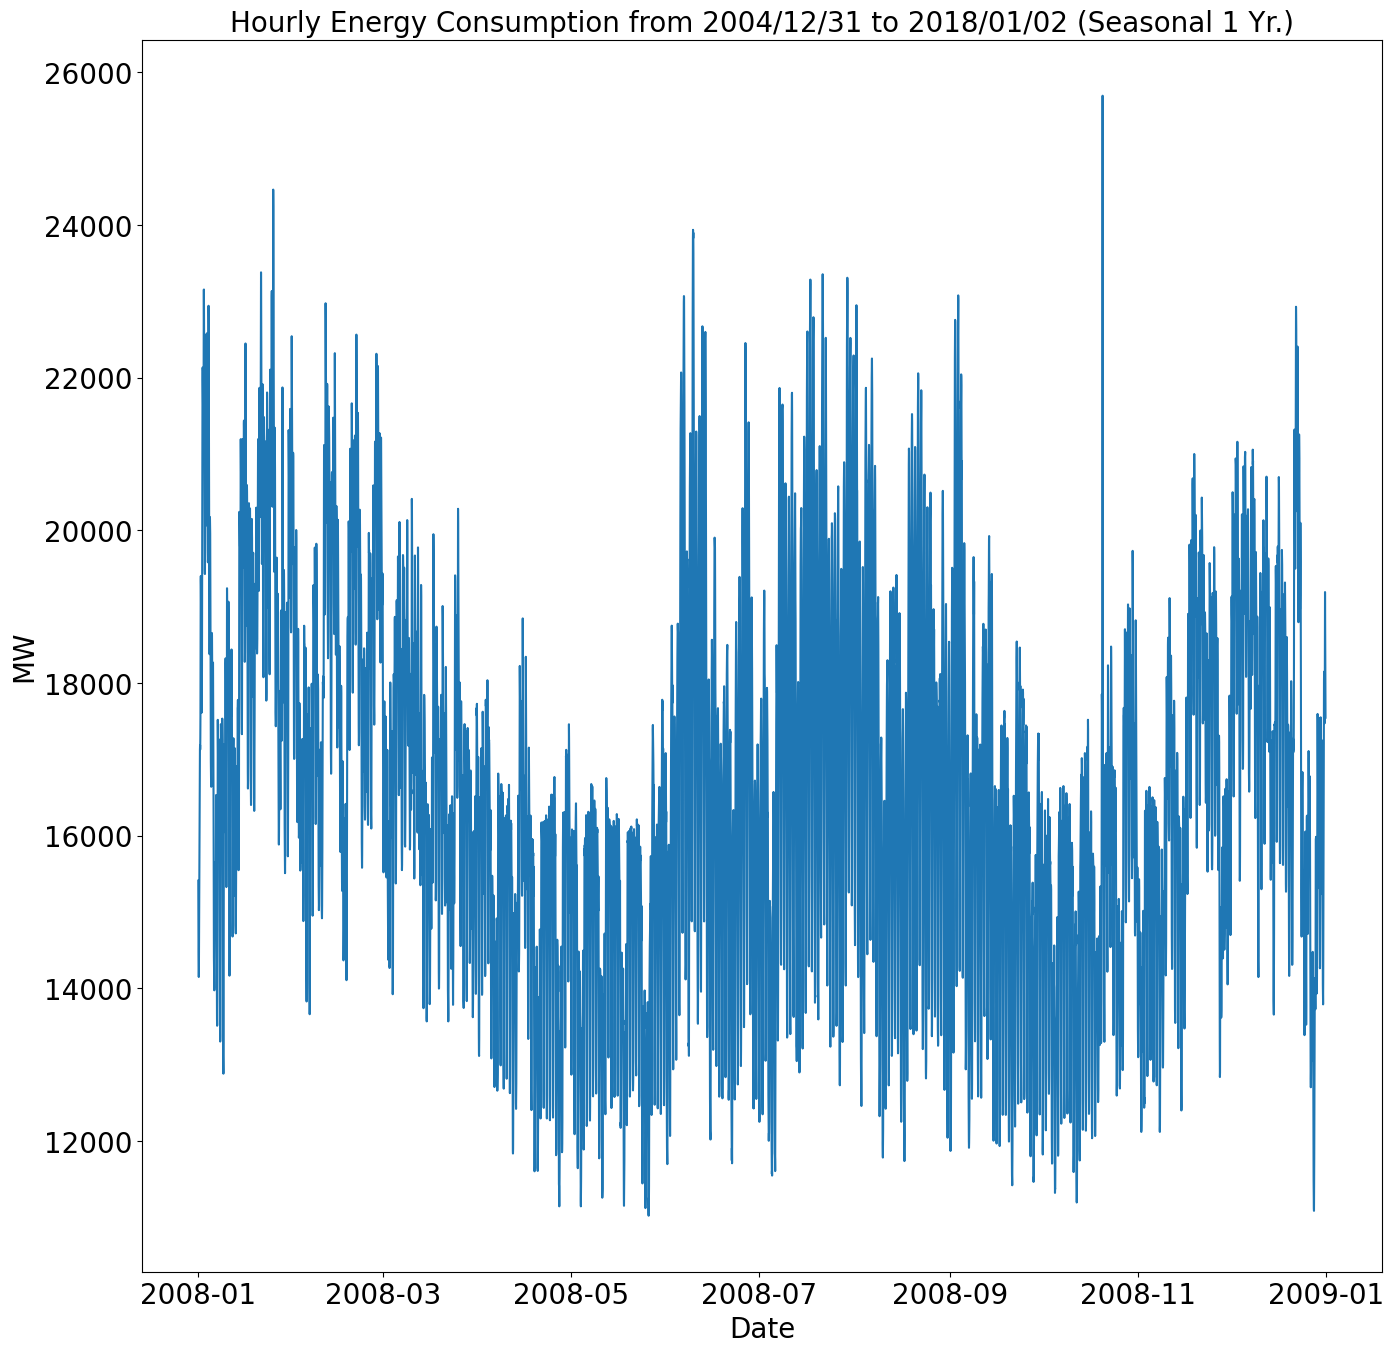

In [18]:
plot_aep_hr(yearly_df, 0, yearly_df.shape[0]-1, "Seasonal 1 Yr.",
                 title_name, 'MW')

### Monthly Plots (Seasonality)

In [19]:
monthly_df = df_entire.query("Datetime >= '2008-05-01' \
                       and Datetime <= '2008-06-01'")

monthly_df

,AEP_MW
Datetime,
2008-05-01 00:00:00,14044
2008-05-01 01:00:00,13230
2008-05-01 02:00:00,12982
2008-05-01 03:00:00,12869
2008-05-01 04:00:00,12878
...,...
2008-05-31 20:00:00,16532
2008-05-31 21:00:00,16178
2008-05-31 22:00:00,16316


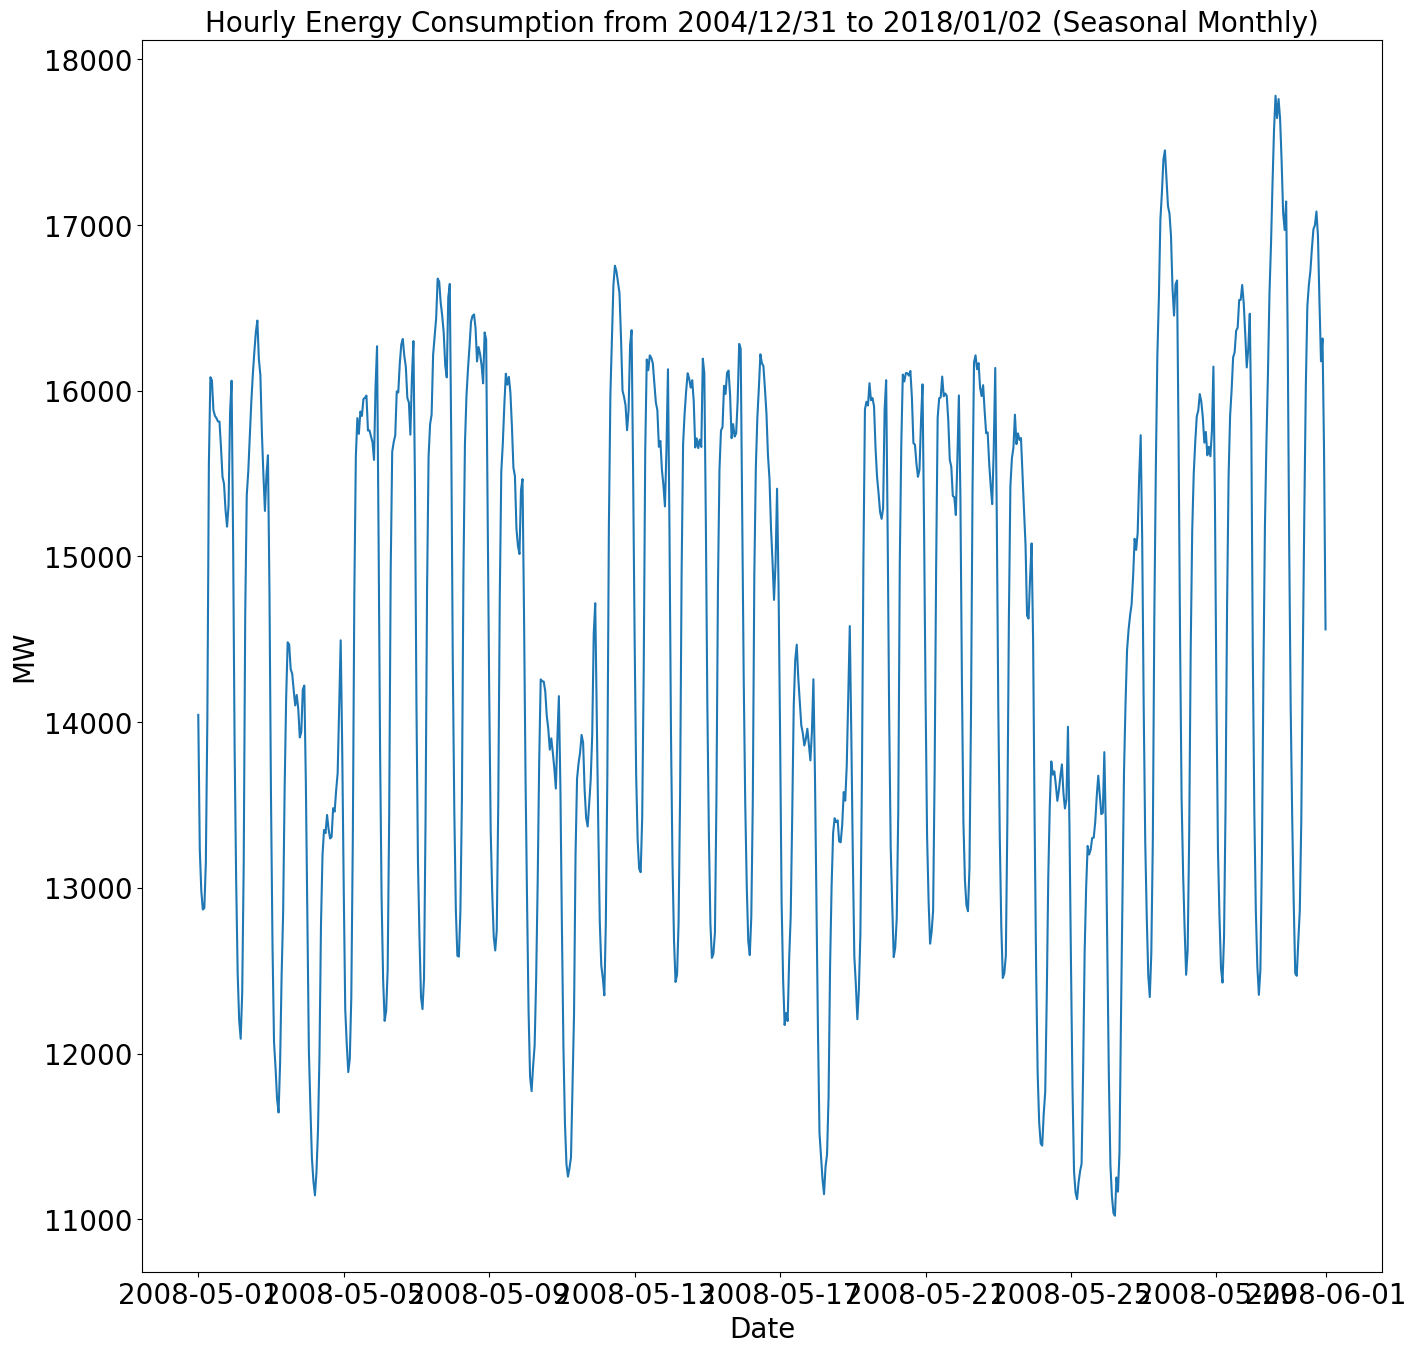

In [20]:
plot_aep_hr(monthly_df, 0, monthly_df.shape[0], "Seasonal Monthly", title_name,
            'MW')

### Daily Plots (Seasonality)

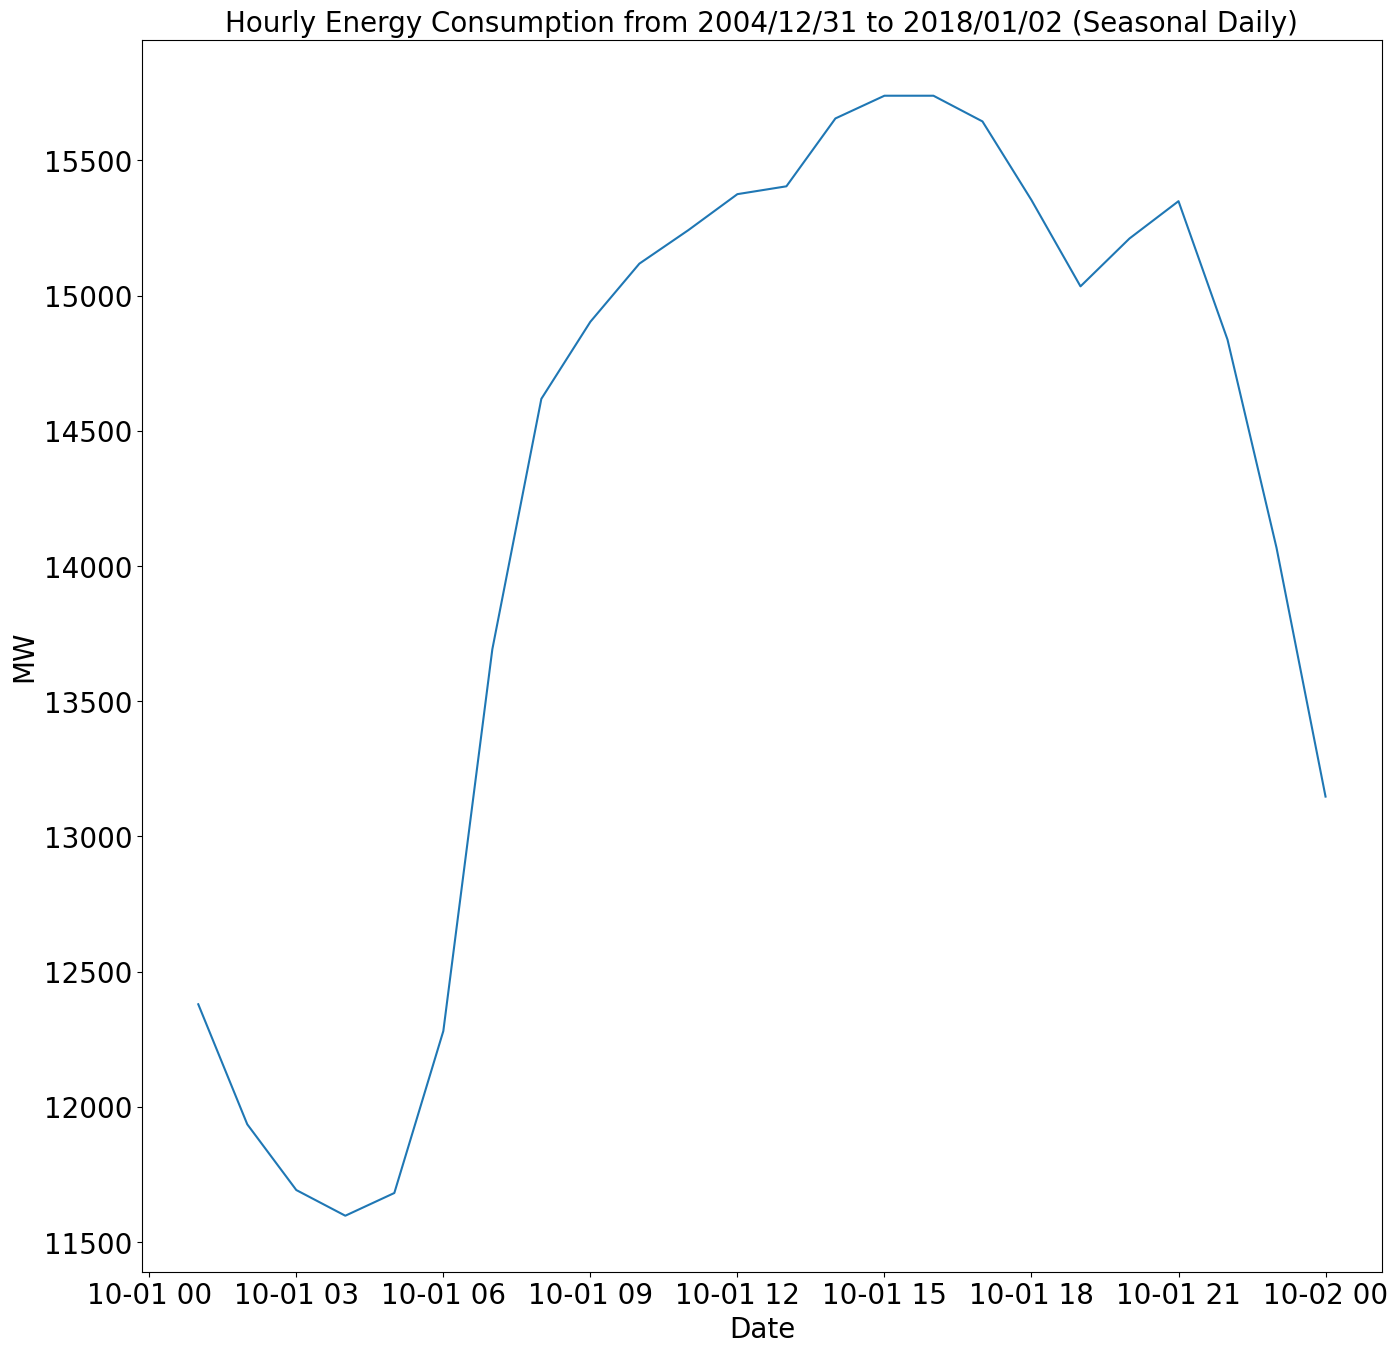

In [21]:
plot_aep_hr(df_entire, 0, 24, "Seasonal Daily", title_name, 'MW')

### Weekly Plots (Seasonality)

In [22]:
weekly_df = df_entire.query("Datetime >= '2008-05-04' \
                       and Datetime <= '2008-05-10'")
weekly_df

,AEP_MW
Datetime,
2008-05-04 00:00:00,12816
2008-05-04 01:00:00,12017
2008-05-04 02:00:00,11677
2008-05-04 03:00:00,11369
2008-05-04 04:00:00,11230
...,...
2008-05-09 20:00:00,15015
2008-05-09 21:00:00,15401
2008-05-09 22:00:00,15467


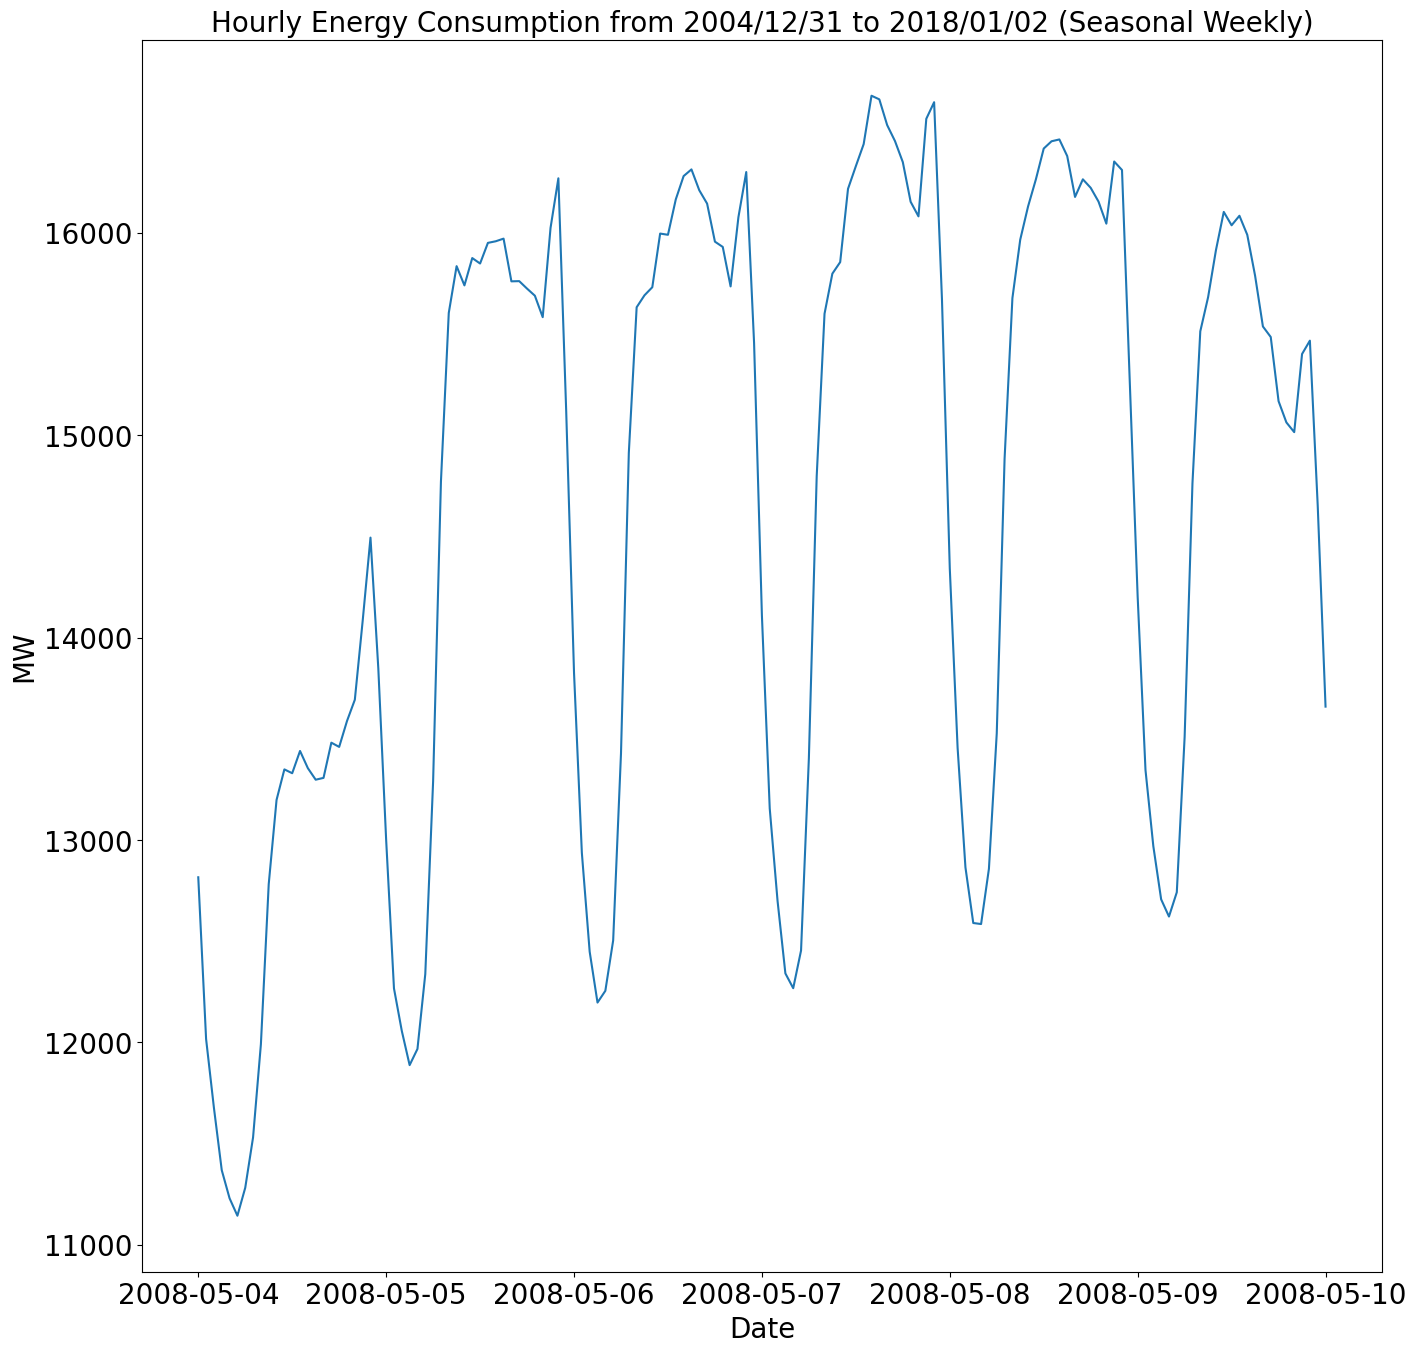

In [23]:
plot_aep_hr(weekly_df, 0, weekly_df.shape[0], "Seasonal Weekly", title_name,
            'MW')

# Normalization Process

In [24]:
def get_scaler(scaler):
    scalers = {
        "minmax": MinMaxScaler,
        "standard": StandardScaler,
        "maxabs": MaxAbsScaler,
        "robust": RobustScaler,
    }
    return scalers.get(scaler.lower())()

def normalize_data(df):
    scaler_type = 'minmax'
    #scaler_type = input("Enter a scaler type (minmax,standard, maxabs, robust): ")
    if (scaler_type != 'minmax') and (scaler_type != 'standard') and (scaler_type != 'maxabs') and (scaler_type != 'robust'):
      runtime.unassign()

    scaler = get_scaler(scaler_type)
    normalized_data_MMT = scaler.fit_transform(df['AEP_MW'].
                                               values.reshape(-1,1))
    df['AEP_MW_Norm'] = normalized_data_MMT
    return df, scaler

df_norm, scaler = normalize_data(df_entire)
df_norm_yr, scaler_yr = normalize_data(yearly_df)
df_norm_mon, scaler_mon = normalize_data(monthly_df)
df_norm_wk, scaler = normalize_data(weekly_df)

In [25]:
df_norm

,AEP_MW,AEP_MW_Norm
Datetime,,
2004-10-01 01:00:00,12379,0.173638
2004-10-01 02:00:00,11935,0.146084
2004-10-01 03:00:00,11692,0.131004
2004-10-01 04:00:00,11597,0.125109
2004-10-01 05:00:00,11681,0.130321
...,...,...
2018-08-02 20:00:00,17673,0.502172
2018-08-02 21:00:00,17303,0.479211
2018-08-02 22:00:00,17001,0.460469


# Let's observe train and test data on the graph

## Split into Train/Test Data.

In [26]:
test_size = 0.2 # Set Split rate to 4:1 (80 % Training 20 % Test).
split_pos = int(df_entire.shape[0]*(1 - test_size))
df_entire = df_entire.reset_index()
df_entire

,Datetime,AEP_MW,AEP_MW_Norm
0,2004-10-01 01:00:00,12379,0.173638
1,2004-10-01 02:00:00,11935,0.146084
2,2004-10-01 03:00:00,11692,0.131004
3,2004-10-01 04:00:00,11597,0.125109
4,2004-10-01 05:00:00,11681,0.130321
...,...,...,...
121268,2018-08-02 20:00:00,17673,0.502172
121269,2018-08-02 21:00:00,17303,0.479211
121270,2018-08-02 22:00:00,17001,0.460469
121271,2018-08-02 23:00:00,15964,0.396115


In [27]:
# 2019-02-06 will be the date seperation. Dates past this will be the test set.
split_date = str(df_entire.Datetime[split_pos])
#split_date = split_date[:10]
#DOM_train = df_norm.loc[df_norm.index <= split_date].copy()
DOM_train = df_entire.loc[df_norm.index <= split_date].copy()
#DOM_test = df_norm.loc[df_norm.index > split_date].copy()
DOM_test = df_entire.loc[df_norm.index > split_date].copy()
split_date

'2015-10-27 10:00:00'

## Plot Train/Test Split Graphs.

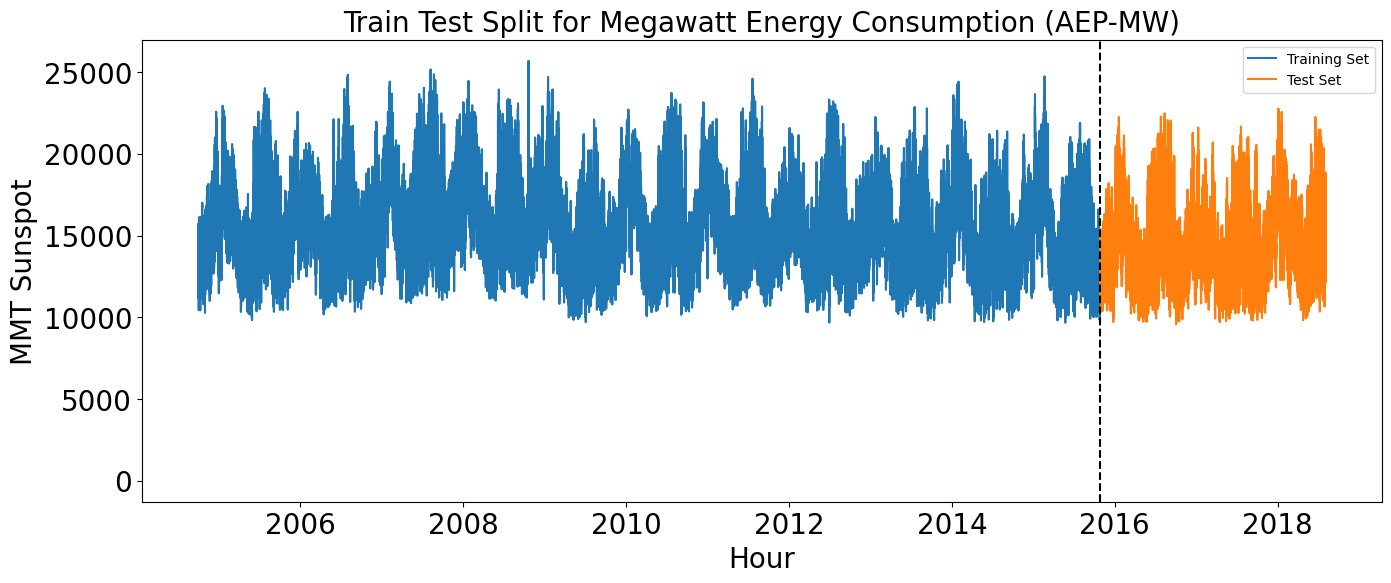

In [28]:
# Monthly Mean Total Sunspot Number Train Test Split
plt.figure(figsize=(16,6))
plt.plot(DOM_train['Datetime'], DOM_train['AEP_MW'],
         label='Training Set (Vehicle Miles)')
plt.plot(DOM_test['Datetime'], DOM_test['AEP_MW'],
         label='Testing Set (Vehicle Miles)')
plt.axvline(x = df_entire.Datetime[split_pos], color='black', ls='--')
plt.legend(['Training Set', 'Test Set'])
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.xlabel("Hour", fontsize = 20)
plt.ylabel("MMT Sunspot", fontsize = 20)
plt.title("Train Test Split for Megawatt Energy Consumption (AEP-MW)",
          fontsize = 20)
plt.show()

In [29]:
# We index the Datetime column after transformation
df_entire.set_index('Datetime', inplace=True)
df_entire.head()

,AEP_MW,AEP_MW_Norm
Datetime,,
2004-10-01 01:00:00,12379,0.173638
2004-10-01 02:00:00,11935,0.146084
2004-10-01 03:00:00,11692,0.131004
2004-10-01 04:00:00,11597,0.125109
2004-10-01 05:00:00,11681,0.130321


In [30]:
df_entire1 = df_entire.drop(columns = ['AEP_MW_Norm'])
df_entire1

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379
2004-10-01 02:00:00,11935
2004-10-01 03:00:00,11692
2004-10-01 04:00:00,11597
2004-10-01 05:00:00,11681
...,...
2018-08-02 20:00:00,17673
2018-08-02 21:00:00,17303
2018-08-02 22:00:00,17001


In [31]:
df_entire2 = df_entire.drop(columns = ['AEP_MW'])
df_entire2

,AEP_MW_Norm
Datetime,
2004-10-01 01:00:00,0.173638
2004-10-01 02:00:00,0.146084
2004-10-01 03:00:00,0.131004
2004-10-01 04:00:00,0.125109
2004-10-01 05:00:00,0.130321
...,...
2018-08-02 20:00:00,0.502172
2018-08-02 21:00:00,0.479211
2018-08-02 22:00:00,0.460469


# Prepare Data for Training the Models.

* With the following function block, let's set our data set as training and test data set in a model appropriate way

In [32]:
def load_data(data, seq_len):
    X_train = []
    y_train = []

    for i in range(seq_len, len(data)):
        X_train.append(data.iloc[i-seq_len : i, 0])
        y_train.append(data.iloc[i, 0])

    # last days are going to be used in test
    X_test = X_train[split_pos:]
    y_test = y_train[split_pos:]

    # first  days are going to be used in training
    X_train = X_train[:split_pos]
    y_train = y_train[:split_pos]

    # convert to numpy array
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # reshape data for input into (samples, timesteps = seq_len, features = 1).
    X_train = np.reshape(X_train, (split_pos, seq_len, 1))
    X_test = np.reshape(X_test, (X_test.shape[0], seq_len, 1))

    return [X_train, y_train, X_test, y_test]

* The **seq_len** parameter determines how far back the model will look at historical data, helping the model to capture time dependencies. This will be the timesteps we will use.
* We should note that if **seq_len** is too large, the model can become complex and prone to overlearning. For purposes of this implementation, **seq_len** will be fixed to 20 for all models.

In [33]:
feature = 'Hourly Energy Consumption'
#selected_df = df_entire1
selected_df = df_entire2
feature_norm = 'Energy Consumption (Norm)'
feature_field = 'Energy Consumption'

In [34]:
seq_len = 20
#seq_len = 6*24*30

# Let's create train, test data
#X_train, y_train, X_test, y_test = load_data(df_vht, seq_len)
#X_train, y_train, X_test, y_test = load_data(df_vmt, seq_len)
X_train, y_train, X_test, y_test = load_data(selected_df, seq_len)
#X_train, y_train, X_test, y_test = load_data(df_norm2, seq_len)


print('X_train.shape = ',X_train.shape)
print('y_train.shape = ', y_train.shape)
print('X_test.shape = ', X_test.shape)
print('y_test.shape = ',y_test.shape)

X_train.shape =  (97018, 20, 1)
y_train.shape =  (97018,)
X_test.shape =  (24235, 20, 1)
y_test.shape =  (24235,)


In [35]:
X_train

array([[[0.17363783],
        [0.14608415],
        [0.1310041 ],
        ...,
        [0.35819784],
        [0.33840139],
        [0.34938563]],

       [[0.14608415],
        [0.1310041 ],
        [0.1251086 ],
        ...,
        [0.33840139],
        [0.34938563],
        [0.35794961]],

       [[0.1310041 ],
        [0.1251086 ],
        [0.13032146],
        ...,
        [0.34938563],
        [0.35794961],
        [0.326176  ]],

       ...,

       [[0.27621944],
        [0.32803773],
        [0.326176  ],
        ...,
        [0.20404617],
        [0.16842497],
        [0.1520417 ]],

       [[0.32803773],
        [0.326176  ],
        [0.34541393],
        ...,
        [0.16842497],
        [0.1520417 ],
        [0.13478962]],

       [[0.326176  ],
        [0.34541393],
        [0.32363162],
        ...,
        [0.1520417 ],
        [0.13478962],
        [0.12566712]]])

In [36]:
X_test

array([[[0.34541393],
        [0.32363162],
        [0.31879111],
        ...,
        [0.13478962],
        [0.12566712],
        [0.14205039]],

       [[0.32363162],
        [0.31879111],
        [0.31699144],
        ...,
        [0.12566712],
        [0.14205039],
        [0.18052625]],

       [[0.31879111],
        [0.31699144],
        [0.31202681],
        ...,
        [0.14205039],
        [0.18052625],
        [0.25915353]],

       ...,

       [[0.18654586],
        [0.16848703],
        [0.15377932],
        ...,
        [0.52978776],
        [0.50217202],
        [0.47921062]],

       [[0.16848703],
        [0.15377932],
        [0.16401887],
        ...,
        [0.50217202],
        [0.47921062],
        [0.46046916]],

       [[0.15377932],
        [0.16401887],
        [0.19858508],
        ...,
        [0.47921062],
        [0.46046916],
        [0.39611518]]])

In [37]:
y_train

array([0.35794961, 0.326176  , 0.27839146, ..., 0.13478962, 0.12566712,
       0.14205039])

In [38]:
y_test

array([0.18052625, 0.25915353, 0.30817922, ..., 0.46046916, 0.39611518,
       0.32443838])

In [39]:
training_dates = df_entire.index[seq_len : seq_len + X_train.shape[0]]
testing_dates = df_entire.index[seq_len + X_train.shape[0] : ]

## Essential Variables.

In [40]:
epochs = 10
#batch_size = 32 # For GPU AND TPU
#batch_size = 6030 # If GPU and TPU not available
batch_size = 642 # Alternate Batch size
#loss = 'MAE'
loss = 'MSE'
activations = ['tanh', 'relu']
#activation = 'tanh'
#activation = 'relu'
units = [8, 16, 32, 64]
filters = [8, 16, 32, 64]
kernel_sizes = [3, 5] # Renamed 'kernel' to 'kernel_sizes' to avoid conflict
a = input("Enter the number of filters: ")
b = input("Enter the number of units: ")
c = input("Enter the number of kernels: ")
d = input("Select an activation index: ")

# Prioritize smaller models for memory efficiency if inputs are invalid
unit = units[0] if not b.isdigit() else units[int(b) % len(units)]
filter = filters[0] if not a.isdigit() else filters[int(a) % len(filters)]
kernel = kernel_sizes[0] if not c.isdigit() else kernel_sizes[int(c) % len(kernel_sizes)]
activation = activations[0] if not d.isdigit() else activations[int(d) % len(activations)]

# Consider enabling mixed precision for further memory reduction if needed (e.g., tf.keras.mixed_precision.set_global_policy('mixed_float16'))

Enter the number of filters: 2
Enter the number of units: 2
Enter the number of kernels: 0
Select an activation index: 0


## Training Loss vs. Epochs Plot

Plotting Accuracy and Validation Accuracy vs Epochs. Code taken from https://machinelearningmastery.com/display-deep-learning-model-training-history-in-keras/.

In [41]:
def plot_training_loss(model, model_name):
    model.history.keys()
    plt.plot(model.history['loss'])
    plt.title('Training Loss vs. Epochs for {0}'.format(model_name))
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()

In [42]:
@keras.saving.register_keras_serializable()
class LIFNeuron(tf.keras.layers.Layer):
    def __init__(self, threshold=0.5, leak_rate=0.001, **kwargs):
        super(LIFNeuron, self).__init__(**kwargs)
        self.threshold = threshold
        self.leak_rate = leak_rate

    def build(self, input_shape):
        self.membrane_potential = self.add_weight(
            name='membrane_potential',
            shape=(input_shape[-1],),  # Shape based on input features
            initializer='zeros',
            trainable=False
        )

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        num_features = input_shape[2]

        # Initialize batch of membrane potentials
        batch_membrane_potential = tf.tile(
            tf.expand_dims(self.membrane_potential, axis=0),
            [batch_size, 1]
        )

        # Initialize output tensor
        outputs = tf.TensorArray(dtype=tf.float32, size=seq_len)

        # Iterate over time steps using tf.while_loop
        t = tf.constant(0)
        while_condition = lambda t, outputs, batch_membrane_potential: tf.less(t, seq_len)

        def while_body(t, outputs, batch_membrane_potential):
            current_input = inputs[:, t, :]
            batch_membrane_potential = batch_membrane_potential * (1 - self.leak_rate) + current_input
            spikes = tf.cast(batch_membrane_potential >= self.threshold, dtype=tf.float32)
            batch_membrane_potential = batch_membrane_potential * (1 - spikes)
            outputs = outputs.write(t, spikes)
            t = tf.add(t, 1)
            return t, outputs, batch_membrane_potential

        _, outputs, _ = tf.while_loop(while_condition, while_body, [t, outputs, batch_membrane_potential])

        outputs = outputs.stack()  # Stack the outputs from the TensorArray
        outputs = tf.transpose(outputs, [1, 0, 2])  # Reshape to (batch_size, seq_len, num_features)

        return outputs

In [43]:
'''class LIFNeuron(tf.keras.layers.Layer):
    def __init__(self, threshold=0.5, leak_rate=0.001, **kwargs):
        super(LIFNeuron, self).__init__(**kwargs)
        self.threshold = threshold
        self.leak_rate = leak_rate

    def build(self, input_shape):
        self.membrane_potential = self.add_weight(
            name='membrane_potential',
            shape=(input_shape[-1],),  # Shape based on input features
            initializer='zeros',
            trainable=False
        )

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        num_features = input_shape[2]

        # Initialize batch of membrane potentials
        batch_membrane_potential = tf.tile(
            tf.expand_dims(self.membrane_potential, axis=0),
            [batch_size, 1]
        )

        # Initialize output tensor
        outputs = tf.TensorArray(dtype=tf.float32, size=seq_len)

        # Iterate over time steps using tf.while_loop
        t = tf.constant(0)
        while_condition = lambda t, outputs, batch_membrane_potential: tf.less(t, seq_len)

        def while_body(t, outputs, batch_membrane_potential):
            current_input = inputs[:, t, :]
            batch_membrane_potential = batch_membrane_potential * (1 - self.leak_rate) + current_input
            spikes = tf.cast(batch_membrane_potential >= self.threshold, dtype=tf.float32)
            batch_membrane_potential = batch_membrane_potential * (1 - spikes)
            outputs = outputs.write(t, spikes)
            t = tf.add(t, 1)
            return t, outputs, batch_membrane_potential

        _, outputs, _ = tf.while_loop(while_condition, while_body, [t, outputs, batch_membrane_potential])

        outputs = outputs.stack()  # Stack the outputs from the TensorArray
        outputs = tf.transpose(outputs, [1, 0, 2])  # Reshape to (batch_size, seq_len, num_features)

        return outputs'''

"class LIFNeuron(tf.keras.layers.Layer):\n    def __init__(self, threshold=0.5, leak_rate=0.001, **kwargs):\n        super(LIFNeuron, self).__init__(**kwargs)\n        self.threshold = threshold\n        self.leak_rate = leak_rate\n\n    def build(self, input_shape):\n        self.membrane_potential = self.add_weight(\n            name='membrane_potential',\n            shape=(input_shape[-1],),  # Shape based on input features\n            initializer='zeros',\n            trainable=False\n        )\n\n    def call(self, inputs):\n        input_shape = tf.shape(inputs)\n        batch_size = input_shape[0]\n        seq_len = input_shape[1]\n        num_features = input_shape[2]\n\n        # Initialize batch of membrane potentials\n        batch_membrane_potential = tf.tile(\n            tf.expand_dims(self.membrane_potential, axis=0),\n            [batch_size, 1]\n        )\n\n        # Initialize output tensor\n        outputs = tf.TensorArray(dtype=tf.float32, size=seq_len)\n\n      

## New LIF Class using Refractory Period

In [44]:
@keras.saving.register_keras_serializable()
class LIFNeuronV3(tf.keras.layers.Layer):
  def __init__(self, threshold=1.0, leak_rate=0.05, refractory_period=5, **kwargs):
      super(LIFNeuronV3 , self).__init__(**kwargs)
      self.threshold = threshold
      self.leak_rate = leak_rate
      self.refractory_period = refractory_period
      self.membrane_potential = None
      self.return_sequences = True # Flag to return output sequence

  def build(self, input_shape):
    self.num_neurons = input_shape[-1]  # Store the number of neurons
    self.membrane_potential = self.add_weight(
          name='membrane_potential',
          #shape=(input_shape[0], input_shape[-1]),
          #shape=(None, self.num_neurons),
          #shape=(input_shape[1], input_shape[-1]),
          #shape=(seq_len, num_features),  # Use Python integers
          shape=(1, self.num_neurons),
          initializer='zeros',
          trainable=False

      )

    self.refractory_counter = self.add_weight(
            name='refractory_counter',
            shape = (),
            #shape=(self.num_neurons,),
            #shape=(1, self.num_neurons),
            initializer='zeros',
            trainable=False,
            dtype=tf.int32  # Ensure refractory_counter is an integer type
        )


  def call(self, inputs):
      input_shape = tf.shape(inputs)
      inputs = tf.reshape(inputs, (input_shape[0], input_shape[1], input_shape[2]))

      # Replace for loop with tf.while_loop
      def while_body(t, sample_outputs_ta, membrane_potential, refractory_counter, sample):
          current_input = tf.gather(sample, t, axis=0)  # Get input at time step t
          membrane_potential = membrane_potential * (1 - self.leak_rate) + current_input

          # Check refractory period
          spikes = tf.cond(
              refractory_counter > 0,
              lambda: tf.zeros_like(membrane_potential),
              lambda: tf.cast(membrane_potential >= self.threshold, dtype=tf.float32)
          )

          # Reset potential and update refractory counter
          reset_condition = tf.reduce_any(spikes > 0)
          membrane_potential = tf.cond(reset_condition,
                                      lambda: membrane_potential * (1 - spikes),
                                      lambda: membrane_potential)

          refractory_counter = tf.cond(reset_condition,
                                      #lambda: self.refractory_period,
                                      lambda: tf.constant(self.refractory_period, dtype=tf.int32),
                                      lambda: tf.maximum(0, refractory_counter - 1))

          # Reshape spikes before writing to TensorArray
          spikes = tf.reshape(spikes, (1, self.num_neurons))  # Shape as (1, num_neurons)
          sample_outputs_ta = sample_outputs_ta.write(t, spikes)

          return tf.add(t, 1), sample_outputs_ta, membrane_potential, refractory_counter, sample

      # Initialize loop variables
      t = tf.constant(0)
      max_time_steps = input_shape[1]

      # Execute the loop for each sample in the batch using tf.map_fn
      def process_sample(sample):
          # Initialize TensorArray inside process_sample
          sample_outputs_ta = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)

          _, sample_outputs_ta, _, _, _ = tf.while_loop(
              lambda t, *_: tf.less(t, max_time_steps),
              while_body,
              [t, sample_outputs_ta, self.membrane_potential, self.refractory_counter, sample]
          )
          sample_outputs = sample_outputs_ta.stack()
          return sample_outputs

      # Use tf.map_fn to process each sample in the batch
      outputs = tf.map_fn(process_sample, inputs, dtype=tf.float32)

      return outputs

## Create SpikingActivation Class.

Due to the depreciation of keras_spiking.SpikingActivation, a custom SpikingActivation class is provided below prior to creating the model.

In [45]:
@keras.saving.register_keras_serializable()
class SpikingActivationCell(tf.keras.layers.Layer):
    def __init__(self, activation='tanh', threshold=1.0, **kwargs):
        super(SpikingActivationCell, self).__init__(**kwargs)
        self.activation = activation
        self.threshold = threshold
        self.state_size = 1  # State to store membrane potential

    def build(self, input_shape):
        # The membrane_potential should have the shape of the input features.
        self.membrane_potential = self.add_weight(
            name='membrane_potential',
            shape=(input_shape[-1],),  # Match the input feature shape
            initializer='zeros',
            trainable=False
        )
        super(SpikingActivationCell, self).build(input_shape)

    def call(self, inputs, states):
        prev_membrane_potential = states[0]

        # Apply activation function
        activated_input = tf.keras.activations.get(self.activation)(inputs)

        # Update membrane potential
        membrane_potential = prev_membrane_potential + activated_input

        # Generate spikes based on threshold
        spikes = tf.cast(membrane_potential >= self.threshold, dtype=tf.float32)

        # Reset membrane potential after spike
        membrane_potential = membrane_potential - spikes * self.threshold

        # Return the spikes and the updated membrane potential as the new state
        return spikes, [membrane_potential]

@keras.saving.register_keras_serializable()
class SpikingActivationLayer(tf.keras.layers.RNN):
    def __init__(self, activation='tanh', threshold=1.0, **kwargs):
        cell = SpikingActivationCell(activation=activation, threshold=threshold)
        super(SpikingActivationLayer, self).__init__(cell, **kwargs)


## sMAPE Function

In [46]:
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    # Ensure y_true and y_pred are numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Calculate the absolute difference between true and predicted values
    abs_diff = np.abs(y_true - y_pred)

    # Calculate the sum of absolute true and predicted values, divided by 2
    # Add a small epsilon to the denominator to avoid division by zero
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    epsilon = np.finfo(np.float64).eps # Smallest positive floating-point number

    # Calculate sMAPE
    # Handle cases where denominator might be zero by setting those to zero error
    smape = np.mean(np.where(denominator == 0, 0, abs_diff / denominator)) * 100

    return smape

## Confidence Intervals for MAE and RMSE using Bootstrapping

In [47]:
def calculate_bootstrap_ci(y_true, y_pred, metric_func, n_bootstraps=1000,
                           confidence_level=0.95):
    bootstrap_metrics = []
    n_samples = len(y_true)

    for _ in range(n_bootstraps):
        # Bootstrap resampling with replacement
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_sample = y_true[indices]
        y_pred_sample = y_pred[indices]

        # Calculate the metric for the bootstrapped sample
        metric_value = metric_func(y_true_sample, y_pred_sample)
        bootstrap_metrics.append(metric_value)

    # Calculate the confidence interval
    lower_bound = np.percentile(bootstrap_metrics, (1 - confidence_level) / 2
                                * 100)
    upper_bound = np.percentile(bootstrap_metrics, (1 + confidence_level) / 2
                                * 100)

    return lower_bound, upper_bound

In [48]:
def perform_statistical_tests(y_true, y_pred, model_name):
    print(f"\n--- Statistical Tests for {model_name} ---")

    # Ensure y_pred is flattened if it's a 2D array
    if y_pred.ndim > 1:
        y_pred = y_pred.flatten()

    # Calculate differences for paired tests
    differences = y_true - y_pred

    # Paired t-test
    try:
        t_statistic, p_value_t = scipy.stats.ttest_rel(y_true, y_pred)
        print(f"Paired t-test: t-statistic = {t_statistic:.4f}, p-value = {p_value_t:.4f}")
        if p_value_t < 0.05:
            print("(Result is statistically significant: there is a significant difference between actual and predicted values)")
        else:
            print("(Result is not statistically significant: no significant difference found)")
    except Exception as e:
        print(f"Paired t-test could not be performed: {e}")

    # Wilcoxon signed-rank test (non-parametric alternative to paired t-test)
    try:
        # The Wilcoxon test expects non-zero differences
        non_zero_differences = differences[differences != 0]
        if len(non_zero_differences) > 0:
            wilcoxon_statistic, p_value_wilcoxon = scipy.stats.wilcoxon(non_zero_differences)
            print(f"Wilcoxon Signed-Rank Test: statistic = \
            {wilcoxon_statistic:.4f}, p-value = {p_value_wilcoxon:.4f}")
            if p_value_wilcoxon < 0.05:
                print("(Result is statistically significant: there is a significant difference between actual and predicted values)")
            else:
                print("(Result is not statistically significant: no significant difference found)")
        else:
            print("Wilcoxon Signed-Rank Test skipped: All differences are zero.")
    except Exception as e:
        print(f"Wilcoxon Signed-Rank Test could not be performed: {e}")

### Diebold-Mariano Test Functions

In [49]:
def diebold_mariano_test(y_true, y_pred1, y_pred2, h=1, power=2):
    # Ensure inputs are numpy arrays
    y_true = np.array(y_true).flatten()
    y_pred1 = np.array(y_pred1).flatten()
    y_pred2 = np.array(y_pred2).flatten()

    # Calculate loss differentials
    # L(y_true, y_pred) = |y_true - y_pred|^power
    loss1 = np.abs(y_true - y_pred1)**power
    loss2 = np.abs(y_true - y_pred2)**power

    d_t = loss1 - loss2

    # DM statistic calculation
    # Reference: Diebold, F. X., & Mariano, R. S. (1995).
    # "Comparing Predictive Accuracy." Journal of Business & Economic Statistics, 13(3), 253-263.

    n = len(d_t)
    # For h-step ahead forecasts, we need to account for serial correlation
    # up to h-1 lags. The formula for the variance of the sample mean of d_t
    # involves an autocovariance function.

    # For a simple case (h=1), the variance can be estimated using a simple variance.
    # For h > 1, a more robust estimator like Newey-West or a similar HAC estimator is needed.
    # statsmodels.stats.sandwich_covariance.HAC for more advanced usage.
    # For simplicity, here we'll use a basic approach or rely on DescrStatsW for a variance estimate.

    # For non-overlapping, one-step ahead, we can simply test if the mean of d_t is different from zero.
    mean_d = np.mean(d_t)
    std_d = np.std(d_t, ddof=1) # sample standard deviation

    if std_d == 0:
        dm_statistic = 0.0 # If all differences are the same, no variance
        p_value = 1.0
    else:
        dm_statistic = mean_d / (std_d / np.sqrt(n))
        # Two-sided p-value from standard normal distribution (as n is large)
        p_value = 2 * (1 - scipy.stats.norm.cdf(np.abs(dm_statistic)))

    # More robust way using statsmodels if needed, for simplicity sticking to the above.
    # dm_test_res = DescrStatsW(d_t)
    # dm_statistic_robust = dm_test_res.tconfint_mean()[0] # This is not directly the statistic.
    # dm_statistic_robust = dm_test_res.tstat
    # p_value_robust = dm_test_res.pvalue

    return dm_statistic, p_value

# DM test with different powers (MAE or MSE based loss)
def diebold_mariano_mae(y_true, y_pred1, y_pred2, h=1):
    return diebold_mariano_test(y_true, y_pred1, y_pred2, h=h, power=1)

def diebold_mariano_mse(y_true, y_pred1, y_pred2, h=1):
    return diebold_mariano_test(y_true, y_pred1, y_pred2, h=h, power=2)

## Measure ANN Energy

In [50]:
def measure_ann_energy(model, X_test, model_name_str=None):
    # Define general power estimates (in Watts) - these are NOT specific to Colab
    # Use these values for a rough conceptual energy estimation only.
    # Adjust these based on your research or assumptions for typical hardware.
    general_cpu_power_watts = 80 # Example general CPU power under load
    general_gpu_power_watts = 200 # Example general GPU power under load

    print("Measuring inference time and estimating energy on CPU (for ANN)...")
    with tf.device('/CPU:0'):
        # Warm-up pass to ensure operations are ready
        _ = model.predict(X_test[:1], verbose=0)
        start_time_cpu = time.time()
        _ = model.predict(X_test, verbose=0)
        end_time_cpu = time.time()
        cpu_inference_time = end_time_cpu - start_time_cpu
        estimated_cpu_energy = general_cpu_power_watts * cpu_inference_time
        estimated_cpu_energy_uJ = estimated_cpu_energy * 1e6 # Convert to microjoules

    print(f"  CPU Inference Time: {cpu_inference_time:.4f} seconds")
    print(f"  Estimated CPU Energy: {estimated_cpu_energy:.4f} Joules ({estimated_cpu_energy_uJ:.4f} \u00B5J)")

    gpu_inference_time = None
    estimated_gpu_energy_J = None
    estimated_gpu_energy_uJ = None

    if tf.config.list_physical_devices('GPU'):
        print("\nMeasuring inference time and estimating energy on GPU (for ANN)...")
        with tf.device('/GPU:0'):
            _ = model.predict(X_test[:1], verbose=0) # Warm-up
            start_time_gpu = time.time()
            _ = model.predict(X_test, verbose=0)
            end_time_gpu = time.time()
            gpu_inference_time = end_time_gpu - start_time_gpu
            estimated_gpu_energy_J = general_gpu_power_watts * gpu_inference_time
            estimated_gpu_energy_uJ = estimated_gpu_energy_J * 1e6 # Convert to microjoules

        print(f"GPU Inference Time: {gpu_inference_time:.4f} seconds")
        print(f"Estimated GPU Energy: {estimated_gpu_energy_J:.4f} Joules ({estimated_gpu_energy_uJ:.4f} \u00B5J)")
    else:
        print("\nNo GPU available. GPU measurements skipped.")

    return {
        'model_name': model_name_str if model_name_str else (model.name if hasattr(model, 'name') else 'ANN Model'),
        'cpu_inference_time_s': cpu_inference_time,
        'estimated_cpu_energy_J': estimated_cpu_energy,
        'estimated_cpu_energy_uJ': estimated_cpu_energy_uJ,
        'gpu_inference_time_s': gpu_inference_time,
        'estimated_gpu_energy_J': estimated_gpu_energy_J,
        'estimated_gpu_energy_uJ': estimated_gpu_energy_uJ,
        'snn_spike_energy_uJ': None
    }

## Measure SNN Energy

In [51]:
def measure_snn_energy(model, X_test, model_name_str=None):
    # Define general power estimates (in Watts) - these are NOT specific to Colab
    # Use these values for a rough conceptual energy estimation only.
    # Adjust these based on your research or assumptions for typical hardware.
    general_cpu_power_watts = 80  # Example general CPU power under load
    general_gpu_power_watts = 200 # Example general GPU power under load

    # Conceptual energy per spike for a digital SNN neuron in microjoules
    # This is a highly simplified estimate and would vary greatly based on hardware and SNN implementation.
    # A typical biological neuron spike is ~45 pJ (0.000045 nJ). Digital SNNs are more energy intensive.
    # We'll use a conceptual value for a single digital SNN neuron spike.
    conceptual_energy_per_spike_uJ = 0.001 # 1 nJ per spike, converted to microjoules

    print("Measuring inference time and estimating energy on CPU (for SNN)...")
    with tf.device('/CPU:0'):
        _ = model.predict(X_test[:1], verbose=0) # Warm-up
        start_time_cpu = time.time()
        predictions = model.predict(X_test, verbose=0)
        end_time_cpu = time.time()
        cpu_inference_time = end_time_cpu - start_time_cpu
        estimated_cpu_energy = general_cpu_power_watts * cpu_inference_time
        estimated_cpu_energy_uJ = estimated_cpu_energy * 1e6 # Convert to microjoules

    print(f"  CPU Inference Time: {cpu_inference_time:.4f} seconds")
    print(f"  Estimated CPU Energy: {estimated_cpu_energy:.4f} Joules ({estimated_cpu_energy_uJ:.4f} \u00B5J)")

    gpu_inference_time = None
    estimated_gpu_energy_J = None
    estimated_gpu_energy_uJ = None

    if tf.config.list_physical_devices('GPU'):
        print("\nMeasuring inference time and estimating energy on GPU (for SNN)...")
        with tf.device('/GPU:0'):
            _ = model.predict(X_test[:1], verbose=0) # Warm-up
            start_time_gpu = time.time()
            predictions_gpu = model.predict(X_test, verbose=0)
            end_time_gpu = time.time()
            gpu_inference_time = end_time_gpu - start_time_gpu
            estimated_gpu_energy_J = general_gpu_power_watts * gpu_inference_time
            estimated_gpu_energy_uJ = estimated_gpu_energy_J * 1e6 # Convert to microjoules

        print(f"  GPU Inference Time: {gpu_inference_time:.4f} seconds")
        print(f"  Estimated GPU Energy: {estimated_gpu_energy_J:.4f} Joules ({estimated_gpu_energy_uJ:.4f} \u00B5J)")
    else:
        print("\nNo GPU available. GPU measurements skipped.")

    # Estimate total spikes and spike energy for SNNs if applicable
    # This part assumes a way to count spikes within the SNN model.
    # For models built with SpikingActivationLayer, we would need to capture spike counts.
    # For now, we'll make a simplifying assumption or provide a placeholder.
    total_spikes = 0
    # This is a very rough estimate. A more accurate calculation would involve iterating
    # through the spiking layers and summing the spikes generated.
    for layer in model.layers:
        if isinstance(layer, LIFNeuron) or isinstance(layer, LIFNeuronV3) or isinstance(layer, SpikingActivationLayer) or isinstance(layer, SpikingActivationLayer2):
            # This is a placeholder. A real implementation would need to hook into
            # the layer's internal state during prediction to count spikes.
            # For example, by running the model in a debug mode or with custom callbacks.
            # For demonstration, let's assume an average spike rate.
            # If the model produced predictions, it implicitly processed inputs.
            # Let's estimate spikes based on the number of neurons and timesteps.
            try:
                # This is a speculative way to get neuron count; adjust based on actual layer structure
                num_neurons_in_layer = layer.units if hasattr(layer, 'units') else layer.cell.units if hasattr(layer, 'cell') and hasattr(layer.cell, 'units') else 128 # Default to 128 if not found
                estimated_spikes_per_layer = num_neurons_in_layer * X_test.shape[1] * X_test.shape[0] # neurons * timesteps * batch_size
                total_spikes += estimated_spikes_per_layer
            except AttributeError:
                # Handle layers that might not have a 'units' attribute as expected
                pass

    estimated_snn_spike_energy_uJ = total_spikes * conceptual_energy_per_spike_uJ
    if total_spikes > 0:
        print(f"Estimated total spikes: {total_spikes:.0f}")
        print(f"Estimated SNN Spike Energy: {estimated_snn_spike_energy_uJ:.4f} \u00B5J")
    else:
        print("No spiking layers detected or spike energy estimation skipped.")

    return {
        'model_name': model_name_str if model_name_str else model.name if hasattr(model, 'name') else 'SNN Model',
        'cpu_inference_time_s': cpu_inference_time,
        'estimated_cpu_energy_J': estimated_cpu_energy,
        'estimated_cpu_energy_uJ': estimated_cpu_energy_uJ,
        'gpu_inference_time_s': gpu_inference_time,
        'estimated_gpu_energy_J': estimated_gpu_energy_J,
        'estimated_gpu_energy_uJ': estimated_gpu_energy_uJ,
        'snn_spike_energy_uJ': estimated_snn_spike_energy_uJ
    }

# LSTM model

## Create LSTM Model.

In [52]:
lstm_model = Sequential()

#lstm_model.add(LSTM(unit,activation=activation,return_sequences=True,
#                    input_shape=(X_train.shape[1],1)))
#lstm_model.add(Dropout(0.5))

lstm_model.add(LSTM(unit,activation=activation,return_sequences=True,
                    input_shape=(seq_len,1)))
lstm_model.add(Dropout(0.5))

#lstm_model.add(LSTM(unit,activation="sigmoid",return_sequences=True))
#lstm_model.add(Dropout(0.5))

lstm_model.add(LSTM(unit,activation=activation,return_sequences=False))
lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(1))

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

## Train LSTM Model.

Training LSTM model on CPU...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - loss: 0.0241
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0127
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0082
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0060
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0045
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0038
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.0032
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0028
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.0025
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0023


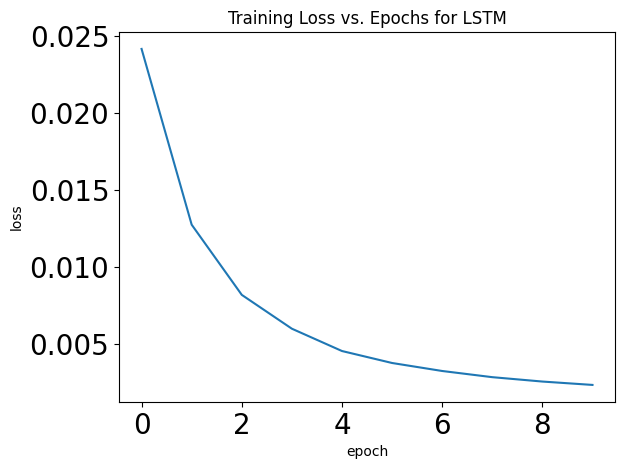

In [53]:
print(f"Training LSTM model on {device}...")
with tf.device('/GPU:0') if device == 'GPU' else tf.device('/CPU:0'): # For TPU, this would be tf.distribute.TPUStrategy
    lstm_model.compile(optimizer="adam",loss=loss)
    lstm_epochs = lstm_model.fit(X_train, y_train, epochs=epochs,
                                 batch_size=batch_size)
plot_training_loss(lstm_epochs, "LSTM")

## Evaluate LSTM model using MAE, RMSE, and R^2.

In [54]:
print("LSTM Predictions for Training Set")
lstm_pred_train = lstm_model.predict(X_train)
print("LSTM Predictions for Testing Set")
lstm_pred_test = lstm_model.predict(X_test)
lstm_mae = mean_absolute_error(y_test,lstm_pred_test)
print("MAE of LSTM model = ",lstm_mae)
lstm_rmse =  mean_squared_error(y_test,lstm_pred_test) ** 0.5
print("RMSE of LSTM model = ",lstm_rmse)
lstm_r2_score = r2_score(y_test, lstm_pred_test)
print("R^2 Score of LSTM model = ",lstm_r2_score)
#lstm_mape_score = symmetric_mean_absolute_percentage_error(y_test,lstm_pred_test)
#print("MAPE Score of LSTM model = {0} %".format(lstm_mape_score))
#lstm_smape_score = 100*symmetric_mean_absolute_percentage_error(y_test,
#                                                                lstm_pred_test)
#print("sMAPE Score of LSTM model = {0} %".format(lstm_smape_score))

LSTM Predictions for Training Set
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step
LSTM Predictions for Testing Set
758/758 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
MAE of LSTM model =  0.020826474879749368
RMSE of LSTM model =  0.02647377601834097
R^2 Score of LSTM model =  0.9695574749723886


In [55]:
perform_statistical_tests(y_test, lstm_pred_test, "LSTM")


--- Statistical Tests for LSTM ---
Paired t-test: t-statistic = -13.0015, p-value = 0.0000
(Result is statistically significant: there is a significant difference between actual and predicted values)
Wilcoxon Signed-Rank Test: statistic =             128934342.0000, p-value = 0.0000
(Result is statistically significant: there is a significant difference between actual and predicted values)


## Calculate 95% Confidence Intervals for LSTM MAE and RMSE

In [56]:
lstm_mae_ci_lower, lstm_mae_ci_upper = calculate_bootstrap_ci(y_test, lstm_pred_test.flatten(), mean_absolute_error)
print(f"LSTM MAE 95% CI: [{lstm_mae_ci_lower:.4f}, {lstm_mae_ci_upper:.4f}]")

lstm_rmse_ci_lower, lstm_rmse_ci_upper = calculate_bootstrap_ci(y_test, lstm_pred_test.flatten(), lambda yt, yp: mean_squared_error(yt, yp)**0.5)
print(f"LSTM RMSE 95% CI: [{lstm_rmse_ci_lower:.4f}, {lstm_rmse_ci_upper:.4f}]")

LSTM MAE 95% CI: [0.0206, 0.0210]
LSTM RMSE 95% CI: [0.0262, 0.0267]


## Reverse Transform Scaler to Convert to Real Values.

In [57]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
lstm_predictions_inv_train = scaler.inverse_transform(lstm_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
lstm_predictions_inv_test = scaler.inverse_transform(lstm_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
lstm_predictions_inv_train = lstm_predictions_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
lstm_predictions_inv_test = lstm_predictions_inv_test.flatten()

## Show Actual and Predicted y values as Dataframes.

### With Training Dates.

In [58]:
results_LSTM_train = pd.DataFrame({"Date":training_dates,
                                   'Actual': y_train_inverse,
                                   'Predicted': lstm_predictions_inv_train})
results_LSTM_train

,Date,Actual,Predicted
0,2004-10-01 21:00:00,13124.535187,12894.601562
1,2004-10-01 22:00:00,12948.731786,12963.367188
2,2004-10-01 23:00:00,12684.339953,12898.523438
3,2004-10-02 00:00:00,12368.443217,12662.817383
4,2004-10-02 01:00:00,12063.877560,12343.492188
...,...,...,...
97013,2015-10-28 01:00:00,12075.895370,12193.672852
97014,2015-10-28 02:00:00,11985.246742,12016.052734
97015,2015-10-28 03:00:00,11889.790989,11993.246094
97016,2015-10-28 04:00:00,11839.316185,12026.652344


### With Testing Dates.


In [59]:
results_LSTM_test = pd.DataFrame({"Date":testing_dates,
                             'Actual': y_test_inverse,
                             'Predicted': lstm_predictions_inv_test})
results_LSTM_test

,Date,Actual,Predicted
0,2015-10-28 06:00:00,12142.851744,12141.865234
1,2015-10-28 07:00:00,12577.896488,12306.771484
2,2015-10-28 08:00:00,12849.155641,12652.378906
3,2015-10-28 09:00:00,12862.203550,12986.187500
4,2015-10-28 10:00:00,12838.511295,13060.422852
...,...,...,...
24230,2018-08-02 20:00:00,13922.517811,13806.581055
24231,2018-08-02 21:00:00,13795.472384,13614.904297
24232,2018-08-02 22:00:00,13691.775847,13487.720703
24233,2018-08-02 23:00:00,13335.705287,13416.474609


## Plotting Predictions for PeMS Dataset Output made by LSTM Model.

### Only Test Data.


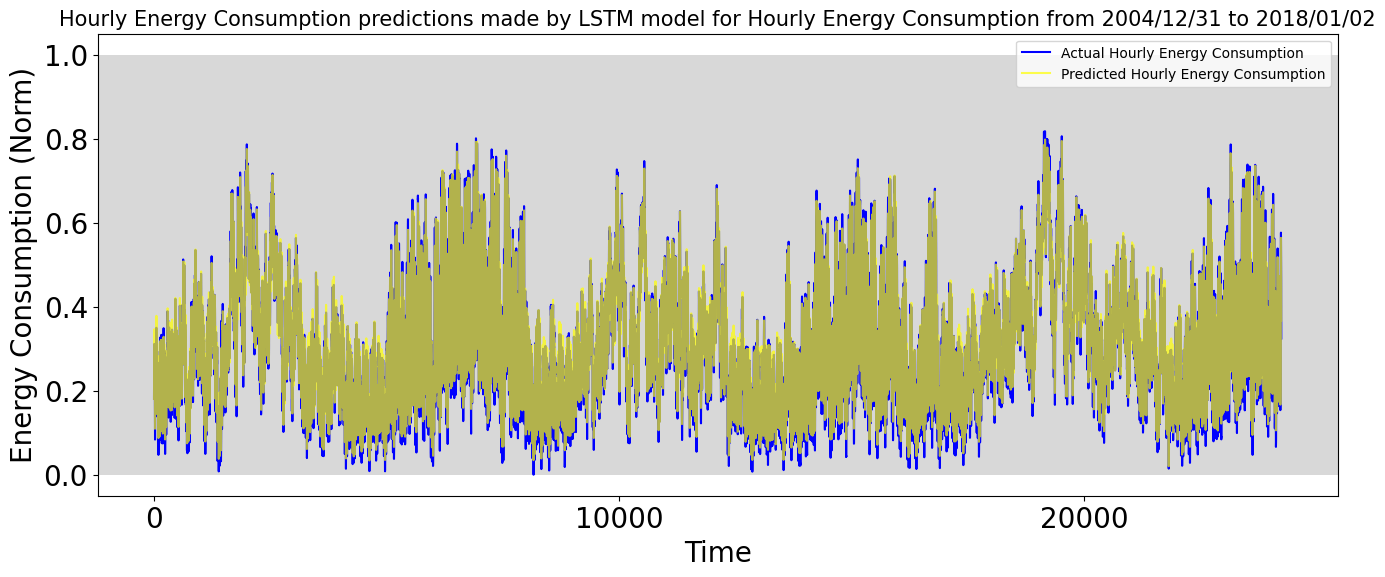

In [60]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(lstm_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} predictions made by LSTM model for {1}".
          format(feature, title_name), fontsize = 15)
plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

### Training and Testing Data combined.

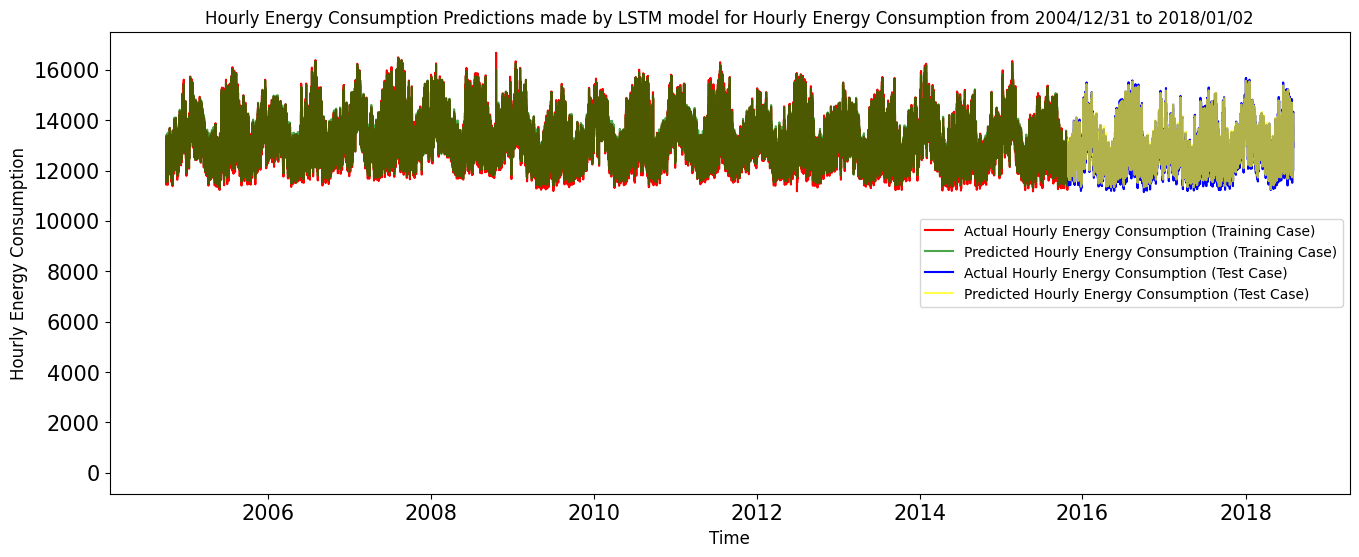

In [61]:
plt.figure(figsize=(16,6))
plt.plot(results_LSTM_train['Date'], results_LSTM_train['Actual'], color='red',
         label='Actual {0} (Training Case)'.format(feature))
plt.plot(results_LSTM_train['Date'],  results_LSTM_train['Predicted'], alpha=0.7,
         color='green', label='Predicted {0} (Training Case)'.format(feature))
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Actual'], color='blue',
         label='Actual {0} (Test Case)'.format(feature))
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Predicted'], alpha=0.7,
         color='yellow', label='Predicted {0} (Test Case)'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by LSTM model for {1}".
          format(feature, title_name))
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 12)
plt.ylabel(feature, fontsize = 12)
plt.legend()
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for LSTM.

In [62]:
results_LSTM = [results_LSTM_train, results_LSTM_test]
results_LSTM = pd.concat(results_LSTM)
display(results_LSTM)

,Date,Actual,Predicted
0,2004-10-01 21:00:00,13124.535187,12894.601562
1,2004-10-01 22:00:00,12948.731786,12963.367188
2,2004-10-01 23:00:00,12684.339953,12898.523438
3,2004-10-02 00:00:00,12368.443217,12662.817383
4,2004-10-02 01:00:00,12063.877560,12343.492188
...,...,...,...
24230,2018-08-02 20:00:00,13922.517811,13806.581055
24231,2018-08-02 21:00:00,13795.472384,13614.904297
24232,2018-08-02 22:00:00,13691.775847,13487.720703
24233,2018-08-02 23:00:00,13335.705287,13416.474609


## Plotting Residuals for Actual and Predicted Results for LSTM.

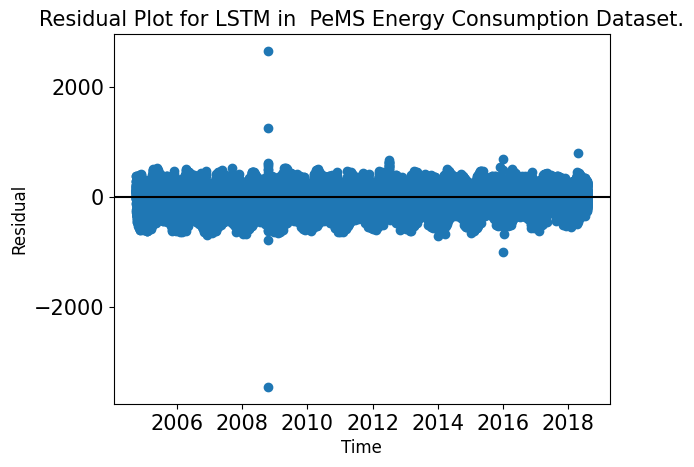

In [63]:
actual_arr_LSTM = np.array(results_LSTM['Actual'])
predicted_arr_LSTM = np.array(results_LSTM['Predicted'])
residuals_LSTM = predicted_arr_LSTM - actual_arr_LSTM
plt.scatter(results_LSTM['Date'], residuals_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plot for LSTM in  PeMS {} Dataset.".format(feature_field),
          fontsize = 15)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 12)
plt.ylabel("Residual", fontsize = 12)
plt.show()

From the residual plots for the LSTM model, it can be concluded that the LSTM model is a good fit.

## Energy Consumption

In [64]:
start_time = time.time()
# Run inference or training with your rnn_model here
end_time = time.time()
execution_time = end_time - start_time
print("Model execution time:", execution_time, "seconds")
lstm_energy_results = measure_ann_energy(lstm_model, X_test, 'LSTM Model')

Model execution time: 5.507469177246094e-05 seconds
Measuring inference time and estimating energy on CPU (for ANN)...
  CPU Inference Time: 3.5084 seconds
  Estimated CPU Energy: 280.6739 Joules (280673904.4189 µJ)

No GPU available. GPU measurements skipped.


# LIF-SNN V3

## Create New SNN and LIF Class

### Spiking Activation Layer

In [65]:
@keras.saving.register_keras_serializable()
class SpikingActivationCell2(tf.keras.layers.Layer):
    def __init__(self, units, threshold=1.0, dt=1.0, spiking_aware_training=False, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.threshold = threshold
        self.dt = dt
        self.spiking_aware_training = spiking_aware_training
        self.state_size = units

    def get_initial_state(self, inputs=None, batch_size=None, dtype=None):
        return [tf.zeros((batch_size, self.units), dtype=dtype or tf.float32)]

    def call(self, inputs, states, training=None):
        prev_v = states[0]

        # Always use tanh for stability
        I = tf.math.tanh(inputs)

        # Membrane update
        v = prev_v + self.dt * I

        # Surrogate gradient spike
        if training and self.spiking_aware_training:
            @tf.custom_gradient
            def spike_fn(x):
                spike = tf.where(x >= self.threshold, 1.0, 0.0)
                def grad(dy):
                    # finite window surrogate
                    return dy * tf.where(tf.abs(x - self.threshold) < 0.5, 1.0, 0.0)
                return spike, grad
            spikes = spike_fn(v)
        else:
            spikes = tf.cast(v >= self.threshold, tf.float32)

        # Reset
        v = tf.where(spikes > 0, v - self.threshold, v)

        return spikes, [v]

@keras.saving.register_keras_serializable()
class SpikingActivationLayer2(tf.keras.layers.RNN):
    def __init__(self, units, activation='tanh', threshold=1.0, dt=1.0,
                 spiking_aware_training=False, **kwargs):
        cell = SpikingActivationCell2(units=units, threshold=threshold, dt=dt,
                                     spiking_aware_training=spiking_aware_training)
        super(SpikingActivationLayer2, self).__init__(cell, **kwargs)
        self.return_sequences = kwargs.get('return_sequences', False)
        self.units = units # Keep units attribute on the layer as well

    def call(self, inputs, initial_state=None, training=None, **kwargs):
        return super(SpikingActivationLayer2, self).call(
            inputs, initial_state=initial_state, training=training, **kwargs
        )

    def compute_output_shape(self, input_shape):
        # input_shape will be (batch_size, timesteps, features_from_prev_layer)
        if self.return_sequences:
            # If return_sequences is True, the output shape includes the time dimension
            # The last dimension will be self.units
            return (input_shape[0], input_shape[1], self.units)
        else:
            # If return_sequences is False, the output shape is (batch_size, self.units)
            return (input_shape[0], self.units)

    def build(self, input_shape):
        super(SpikingActivationLayer2, self).build(input_shape)

### Create Model

In [66]:
spiking_LIFv3_model = tf.keras.Sequential(
    [
        # Add temporal dimension to model. For this dataset, the input_shape is
        # passed into the model.
        tf.keras.layers.Reshape((seq_len, X_train.shape[2]), # Use seq_len here
                                input_shape=(None, X_train.shape[1])),
        # Keras' TimeDistributed wrapper allows Dense layer to operate on
        # temporal data.
        tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(128)),
        #tf.keras.layers.Dense(64, activation='tanh'),
        #LIFNeuronV3(threshold=1.25, leak_rate=0.06, refractory_period=5),
        #tf.keras.layers.Activation('tanh'),  # Non-linearity before LIF
        LIFNeuronV3(threshold=0.5, leak_rate=0.01, refractory_period=275),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Reshape((-1, 128)),  # Reshape to (batch_size, time_steps, features)

        #tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(64)),
        #tf.keras.layers.Activation('tanh'),  # Non-linearity before LIF
        #LIFNeuronV3(threshold=0.5, leak_rate=0.01, refractory_period=5),


        #tf.keras.layers.Dropout(0.01),  # Added dropout
        # Use tf.keras.layers.Permute to swap the time_steps and num_neurons dimensions
        #tf.keras.layers.Permute((2, 1)),  # Now shape is (batch_size, num_neurons, time_steps)
        #tf.keras.layers.Reshape((-1, 64)),  # Reshape to (batch_size, time_steps, num_neurons)
        # GlobalAveragePooling1D: Averages spiking output over time. Used for
        # determining the spiking rate of neuron.
        #keras_spiking.SpikingActivation("tanh", dt = 100,
        #                                spiking_aware_training=True),
        #SpikingActivation(activation=tf.keras.activations.tanh, dt = 100,
        #                  spiking_aware_training=True),
        tf.keras.layers.GlobalAveragePooling1D(),
        #tf.keras.layers.GlobalAveragePooling1D(data_format='channels_last'),
        #tf.keras.layers.Dense(future),
        #tf.keras.layers.Flatten(),  # Add Flatten layer
        #tf.keras.layers.Reshape((batch_size, 1)),  # Reshape to (batch_size, 1)
        #tf.keras.layers.Lambda(lambda x: x[:, -1]),
        tf.keras.layers.Dense(1),
        #tf.keras.layers.Dense(1, input_shape=(X_train.shape[1] * 64, )),

    ]

)
spiking_LIFv3_model.summary()


Instructions for updating:
Use fn_output_signature instead


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 128)        │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lif_neuron_v3 (LIFNeuronV3)     │ (None, None, 1, 128)   │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, None, 1, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 514 (2.01 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 129 (516.00 B)

## Training SNN V3 Model.

Training SNN LIF V3 model on CPU...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - loss: 0.1049
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - loss: 0.0446
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - loss: 0.0283
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 0.0255
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - loss: 0.0252
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 0.0251
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - loss: 0.0251
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - loss: 0.0251
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - loss: 0.0251
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - loss: 0.0251


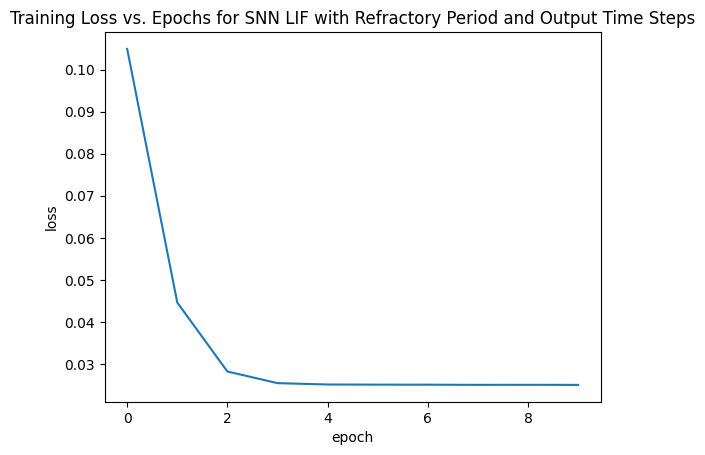

In [67]:
print(f"Training SNN LIF V3 model on {device}...")
with tf.device('/GPU:0') if device == 'GPU' else tf.device('/CPU:0'):
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    spiking_LIFv3_model.compile(optimizer=optimizer, loss=loss)
    spiking_LIFv3_model_epochs = spiking_LIFv3_model.fit(X_train,y_train,epochs=epochs,
                                                     batch_size=batch_size)
plot_training_loss(spiking_LIFv3_model_epochs, "SNN LIF with Refractory Period and Output Time Steps")

## Evaluating SNN V3 Model using MAE, RMSE, R2.

In [68]:
print("SNN v3 Predictions for Training Set")
spiking_LIFv3_model_pred_train = spiking_LIFv3_model.predict(X_train)
print("SNN v3 Predictions for Training Set")
spiking_LIFv3_model_pred_test = spiking_LIFv3_model.predict(X_test)
print(spiking_LIFv3_model_pred_test.shape)

# Reshape the model predictions if necessary
#spiking_LIFv3_model_pred_test = spiking_LIFv3_model_pred_test.reshape(y_test.shape)

spiking_LIFv3_model_mae = mean_absolute_error(y_test, spiking_LIFv3_model_pred_test)
print("MAE of SNN v3model = ",spiking_LIFv3_model_mae)
spiking_LIFv3_model_rmse =  mean_squared_error(y_test, spiking_LIFv3_model_pred_test) ** 0.5
print("RMSE of SNN v3  model = ", spiking_LIFv3_model_rmse)
spiking_LIFv3_model_r2_score = r2_score(y_test, spiking_LIFv3_model_pred_test)
print("R2 Score of SNN v3 model = ", spiking_LIFv3_model_r2_score)
#spiking_LIFv3_model_mape_score = symmetric_mean_absolute_percentage_error(y_test,
#                                                                   spiking_LIFv3_model_pred_test)
#print("MAPE Score of SNN v3 model = {0} %".format(spiking_LIFv3_model_mape_score))

SNN v3 Predictions for Training Set
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 87s 28ms/step
SNN v3 Predictions for Training Set
758/758 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step
(24235, 1)
MAE of SNN v3model =  0.12875780641795126
RMSE of SNN v3  model =  0.15610319366437914
R2 Score of SNN v3 model =  -0.05845516831636455


In [69]:
perform_statistical_tests(y_test, spiking_LIFv3_model_pred_test, "LIF SNN V3")


--- Statistical Tests for LIF SNN V3 ---
Paired t-test: t-statistic = -54.9895, p-value = 0.0000
(Result is statistically significant: there is a significant difference between actual and predicted values)
Wilcoxon Signed-Rank Test: statistic =             86422494.0000, p-value = 0.0000
(Result is statistically significant: there is a significant difference between actual and predicted values)


## Calculate 95% Confidence Intervals for LIF-SNN V3 MAE and RMSE

In [70]:
lifsnnv3_mae_ci_lower, lifsnnv3_mae_ci_upper = calculate_bootstrap_ci(y_test, spiking_LIFv3_model_pred_test.flatten(), mean_absolute_error)
print(f"LIF-SNN V3 MAE 95% CI: [{lifsnnv3_mae_ci_lower:.4f}, {lifsnnv3_mae_ci_upper:.4f}]")

lifsnnv3_rmse_ci_lower, lifsnnv3_rmse_ci_upper = calculate_bootstrap_ci(y_test, spiking_LIFv3_model_pred_test.flatten(), lambda yt, yp: mean_squared_error(yt, yp)**0.5)
print(f"LIF-SNN V3 RMSE 95% CI: [{lifsnnv3_rmse_ci_lower:.4f}, {lifsnnv3_rmse_ci_upper:.4f}]")

LIF-SNN V3 MAE 95% CI: [0.1277, 0.1299]
LIF-SNN V3 RMSE 95% CI: [0.1550, 0.1573]


## Reverse Transform Scaler to Convert to Real Values.

In [71]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
spiking_LIFv3_model_inv_train = scaler.inverse_transform(spiking_LIFv3_model_pred_train)

y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
spiking_LIFv3_model_inv_test = scaler.inverse_transform(spiking_LIFv3_model_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
spiking_LIFv3_model_inv_train = spiking_LIFv3_model_inv_train.flatten()

y_test_inverse = y_test_inverse.flatten()
spiking_LIFv3_model_inv_test = spiking_LIFv3_model_inv_test.flatten()

## Show Actual and Predicted y values as Dataframes.

### With Training Dates.

In [72]:
results_SNN_LIFv3_train = pd.DataFrame({"Date": training_dates,
                                  'Actual': y_train_inverse,
                                  'Predicted': spiking_LIFv3_model_inv_train})
results_SNN_LIFv3_train

,Date,Actual,Predicted
0,2004-10-01 21:00:00,13124.535187,13394.365234
1,2004-10-01 22:00:00,12948.731786,13151.667969
2,2004-10-01 23:00:00,12684.339953,13394.365234
3,2004-10-02 00:00:00,12368.443217,13204.605469
4,2004-10-02 01:00:00,12063.877560,13151.667969
...,...,...,...
97013,2015-10-28 01:00:00,12075.895370,13115.854492
97014,2015-10-28 02:00:00,11985.246742,13204.605469
97015,2015-10-28 03:00:00,11889.790989,13115.854492
97016,2015-10-28 04:00:00,11839.316185,13115.854492


### With Testing Dates.

In [73]:
results_SNN_LIFv3_test = pd.DataFrame({"Date":testing_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': spiking_LIFv3_model_inv_test})
results_SNN_LIFv3_test

,Date,Actual,Predicted
0,2015-10-28 06:00:00,12142.851744,13394.365234
1,2015-10-28 07:00:00,12577.896488,13394.365234
2,2015-10-28 08:00:00,12849.155641,13394.365234
3,2015-10-28 09:00:00,12862.203550,13011.543945
4,2015-10-28 10:00:00,12838.511295,13115.854492
...,...,...,...
24230,2018-08-02 20:00:00,13922.517811,13115.854492
24231,2018-08-02 21:00:00,13795.472384,13204.605469
24232,2018-08-02 22:00:00,13691.775847,13394.365234
24233,2018-08-02 23:00:00,13335.705287,13274.455078


## Plotting Predictions for PeMS Dataset Output made by SNN LIF Model.

### Only Testing Data.

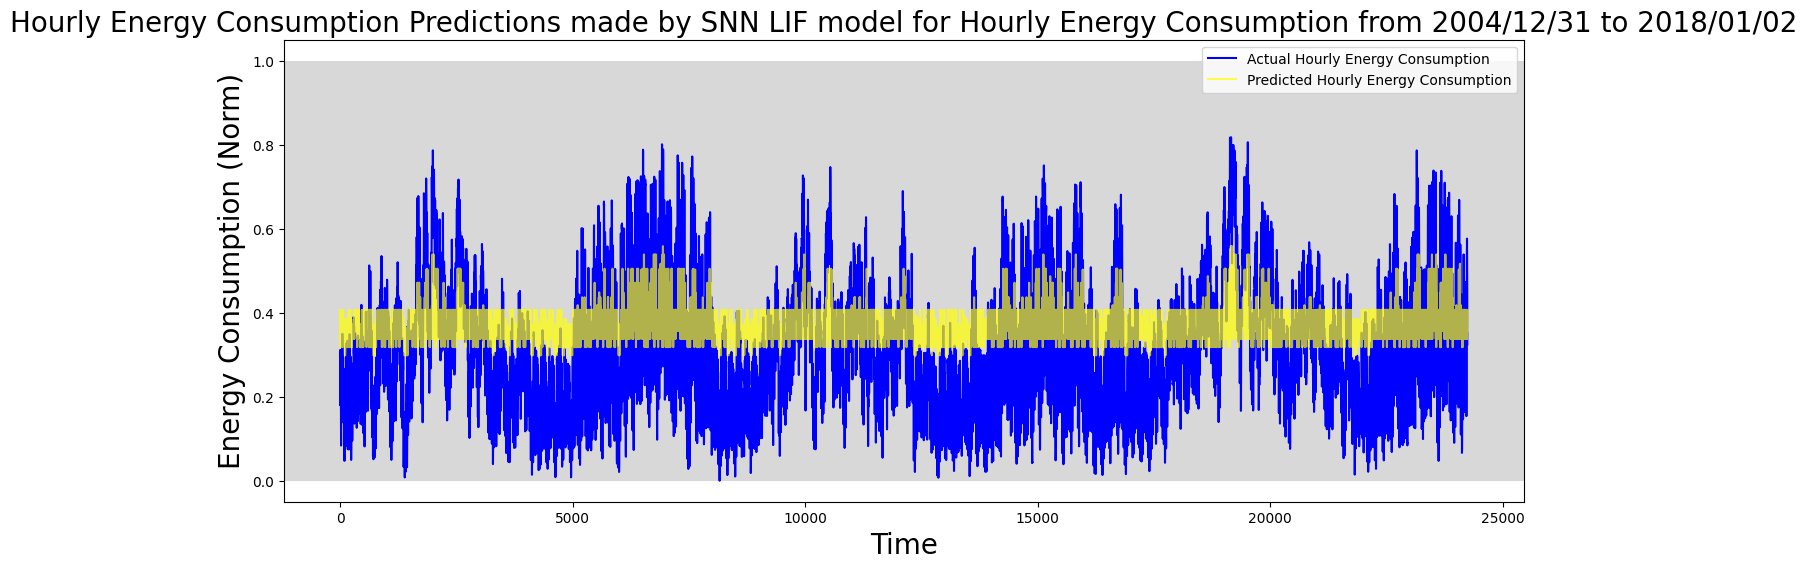

In [74]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(spiking_LIFv3_model_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by SNN LIF model for {1}".
          format(feature, title_name), fontsize = 20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

### Training and Testing Data combined.

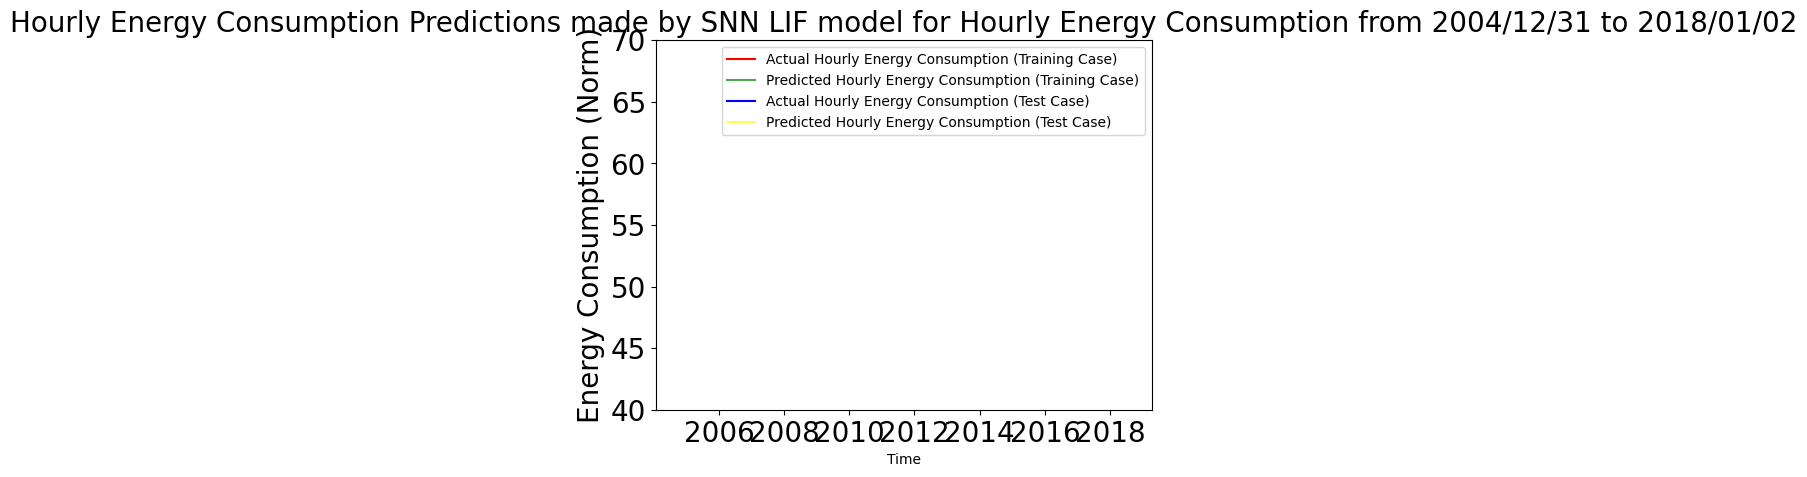

In [75]:
plt.plot(results_SNN_LIFv3_train['Date'], results_SNN_LIFv3_train['Actual'],
         color='red', label='Actual {0} (Training Case)'.format(feature))
plt.plot(results_SNN_LIFv3_train['Date'],  results_SNN_LIFv3_train['Predicted'],
         alpha=0.7, color='green',
         label='Predicted {0} (Training Case)'.format(feature))
plt.plot(results_SNN_LIFv3_test['Date'], results_SNN_LIFv3_test['Actual'],
         color='blue', label='Actual {0} (Test Case)'.format(feature))
plt.plot(results_SNN_LIFv3_test['Date'], results_SNN_LIFv3_test['Predicted'],
         alpha=0.7, color='yellow',
         label='Predicted {0} (Test Case)'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by SNN LIF model for {1}".
          format(feature, title_name), fontsize = 20)
plt.xlabel('Time', fontsize = 10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
plt.ylim([40, 70])
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for SNN LIF Model.

In [76]:
results_SNN_LIFv3 = [results_SNN_LIFv3_train, results_SNN_LIFv3_test]
results_SNN_LIFv3 = pd.concat(results_SNN_LIFv3)
display(results_SNN_LIFv3)

,Date,Actual,Predicted
0,2004-10-01 21:00:00,13124.535187,13394.365234
1,2004-10-01 22:00:00,12948.731786,13151.667969
2,2004-10-01 23:00:00,12684.339953,13394.365234
3,2004-10-02 00:00:00,12368.443217,13204.605469
4,2004-10-02 01:00:00,12063.877560,13151.667969
...,...,...,...
24230,2018-08-02 20:00:00,13922.517811,13115.854492
24231,2018-08-02 21:00:00,13795.472384,13204.605469
24232,2018-08-02 22:00:00,13691.775847,13394.365234
24233,2018-08-02 23:00:00,13335.705287,13274.455078


## Plot Output Spikes
Code taken from https://pythontic.com/visualization/charts/spikerasterplot#:~:text=A%20Spike%20raster%20plot%20is%20a%20plot%20used,potential%20from%20a%20neuron%20at%20a%20specified%20position.

In [77]:
def check_output(seq_model, X_train, X_test, y_train, y_test, modify_dt=0.1):
    """
    This code is used to show the plot of the output spikes for the
    SpikingActivation Layer.
    """
    print("Spike plotting functionality is currently not supported for the custom LIFNeuronV3 layer.")
    print("To enable spike plotting, LIFNeuronV3 would need to be modified to return spike activity, ")
    print("and this function would require a significant overhaul to be compatible.")
    return # Exit the function early as it's not supported

In [78]:
# check_output(spiking_LIFv3_model, X_train, X_test, y_train, y_test)

## Plotting Residuals for Actual and Predicted Results for LIF-SNN V3.

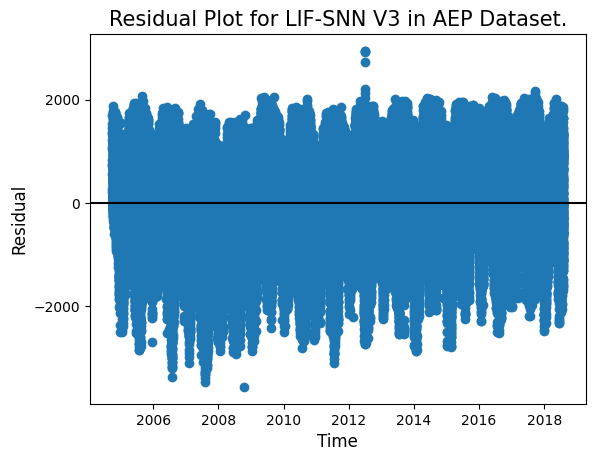

In [79]:
actual_arr_LIFSNNV3 = np.array(results_SNN_LIFv3['Actual'])
predicted_arr_LIFSNNV3 = np.array(results_SNN_LIFv3['Predicted'])
residuals_LIFSNNV3 = predicted_arr_LIFSNNV3 - actual_arr_LIFSNNV3
plt.scatter(results_SNN_LIFv3['Date'], residuals_LIFSNNV3)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plot for LIF-SNN V3 in AEP Dataset.".format(feature_field),
          fontsize = 15)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 12)
plt.ylabel("Residual", fontsize = 12)
plt.show()

## Energy Consumption

In [80]:
spiking_LIFv3_energy_results = measure_snn_energy(spiking_LIFv3_model, X_test,
                                                  model_name_str='LIF SNN V3 Model')

Measuring inference time and estimating energy on CPU (for SNN)...
  CPU Inference Time: 20.9922 seconds
  Estimated CPU Energy: 1679.3800 Joules (1679379997.2534 µJ)

No GPU available. GPU measurements skipped.
Estimated total spikes: 62041600
Estimated SNN Spike Energy: 62041.6000 µJ


# CNN-LSTM model

## Create CNN-LSTM Model.


In [81]:
cnn_lstm_model = Sequential()

cnn_lstm_model.add(Conv1D(filters=filter, kernel_size=kernel, activation=activation,
                         input_shape=(seq_len, X_train.shape[2])))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))

cnn_lstm_model.add(Conv1D(filters=filter, kernel_size=kernel, activation=activation,
                         input_shape=(seq_len, X_train.shape[2])))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))

#cnn_lstm_model.add(Conv1D(filters=60, kernel_size=2, activation='relu',
#input_shape=(seq_len, X_train.shape[2])))
#cnn_lstm_model.add(MaxPooling1D(pool_size=2))

#cnn_lstm_model.add(LSTM(60,activation="tanh",return_sequences=True,
#input_shape=(X_train.shape[1],1)))
#cnn_lstm_model.add(Dropout(0.5))

#cnn_lstm_model.add(LSTM(64,activation="tanh",return_sequences=True))
#cnn_lstm_model.add(Dropout(0.8))

#cnn_lstm_model.add(LSTM(64, activation="tanh",return_sequences=True))
#cnn_lstm_model.add(Dropout(0.8))

cnn_lstm_model.add(LSTM(unit, activation=activation,return_sequences=False))
cnn_lstm_model.add(Dropout(0.1))

cnn_lstm_model.add(Dense(1))
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,585 (45.25 KB)

 Trainable params: 11,585 (45.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train CNN-LSTM Model.

Training CNN-LSTM model on CPU...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0276
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0142
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0065
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0036
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0033
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0031
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0030
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0029
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0027
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0027


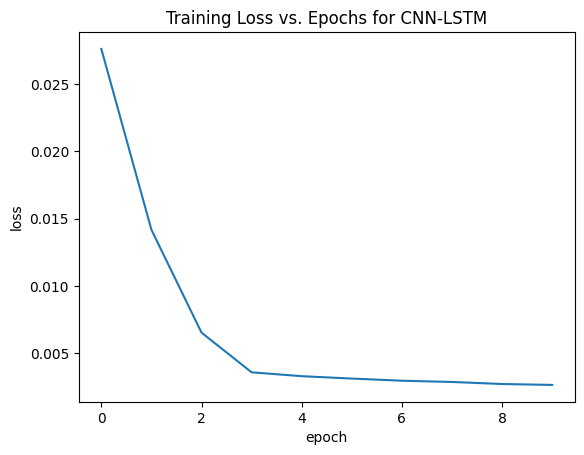

In [82]:
print(f"Training CNN-LSTM model on {device}...")
with tf.device('/GPU:0') if device == 'GPU' else tf.device('/CPU:0'):
    cnn_lstm_model.compile(optimizer="adam",loss=loss)
    cnn_lstm_epochs = cnn_lstm_model.fit(X_train, y_train, epochs=epochs,
                                         batch_size=batch_size)
plot_training_loss(cnn_lstm_epochs, "CNN-LSTM")

## Evaluate CNN-LSTM model using MAE, RMSE, and R^2.

In [83]:
print("CNN-LSTM Predictions for Training Set")
cnn_lstm_pred_train = cnn_lstm_model.predict(X_train)
print("CNN-LSTM Predictions for Testing Set")
cnn_lstm_pred_test = cnn_lstm_model.predict(X_test)
cnn_lstm_mae = mean_absolute_error(y_test,cnn_lstm_pred_test)
print("MAE of CNN-LSTM model = ",cnn_lstm_mae)
cnn_lstm_rmse =  mean_squared_error(y_test,cnn_lstm_pred_test) ** 0.5
print("RMSE of CNN-LSTM model = ",cnn_lstm_rmse)
cnn_lstm_r2_score = r2_score(y_test, cnn_lstm_pred_test)
print("R^2 Score of CNN-LSTM model = ",cnn_lstm_r2_score)
#cnn_lstm_mape_score = symmetric_mean_absolute_percentage_error(y_test,
#                                                         cnn_lstm_pred_test)
#print("MAPE Score of CNN-LSTM model = {0} %".format(cnn_lstm_mape_score))

CNN-LSTM Predictions for Training Set
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
CNN-LSTM Predictions for Testing Set
758/758 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE of CNN-LSTM model =  0.03540908083004357
RMSE of CNN-LSTM model =  0.04427360197686389
R^2 Score of CNN-LSTM model =  0.9148590279488956


In [84]:
perform_statistical_tests(y_test, cnn_lstm_pred_test, "CNN-LSTM")


--- Statistical Tests for CNN-LSTM ---
Paired t-test: t-statistic = -45.6766, p-value = 0.0000
(Result is statistically significant: there is a significant difference between actual and predicted values)
Wilcoxon Signed-Rank Test: statistic =             95928702.0000, p-value = 0.0000
(Result is statistically significant: there is a significant difference between actual and predicted values)


## Calculate 95% Confidence Intervals for CNN-LSTM MAE and RMSE

In [85]:
cnn_lstm_mae_ci_lower, cnn_lstm_mae_ci_upper = calculate_bootstrap_ci(
    y_test, cnn_lstm_pred_test.flatten(), mean_absolute_error)
print(f"CNN-LSTM MAE 95% CI: [{cnn_lstm_mae_ci_lower:.4f}, {cnn_lstm_mae_ci_upper:.4f}]")

cnn_lstm_rmse_ci_lower, cnn_lstm_rmse_ci_upper = calculate_bootstrap_ci(
    y_test, cnn_lstm_pred_test.flatten(),
    lambda yt, yp: mean_squared_error(yt, yp)**0.5)
print(f"CNN-LSTM RMSE 95% CI: [{cnn_lstm_rmse_ci_lower:.4f}, {cnn_lstm_rmse_ci_upper:.4f}]")

CNN-LSTM MAE 95% CI: [0.0351, 0.0358]
CNN-LSTM RMSE 95% CI: [0.0439, 0.0447]


## Reverse Transform Scaler to Convert to Real Values.

In [86]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
cnn_lstm_pred_inv_train = scaler.inverse_transform(cnn_lstm_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
cnn_lstm_pred_inv_test = scaler.inverse_transform(cnn_lstm_pred_test)

# Get values after inverse transformation.
y_train_inverse = y_train_inverse.flatten()
cnn_lstm_pred_inv_train = cnn_lstm_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
cnn_lstm_pred_inv_test = cnn_lstm_pred_inv_test.flatten()

## Showing Actual y and Predicted y values as Dataframes.


In [87]:
first_6169_index_dates = selected_df.index[:X_train.shape[0]]
results_CNN_LSTM_train = pd.DataFrame({"Date":first_6169_index_dates,
                                 'Actual': y_train_inverse,
                                 'Predicted': cnn_lstm_pred_inv_train})
results_CNN_LSTM_train

,Date,Actual,Predicted
0,2004-10-01 01:00:00,13124.535187,13101.340820
1,2004-10-01 02:00:00,12948.731786,12806.806641
2,2004-10-01 03:00:00,12684.339953,12546.288086
3,2004-10-01 04:00:00,12368.443217,12297.082031
4,2004-10-01 05:00:00,12063.877560,12294.422852
...,...,...,...
97013,2015-10-27 05:00:00,12075.895370,12165.478516
97014,2015-10-27 06:00:00,11985.246742,12071.385742
97015,2015-10-27 07:00:00,11889.790989,12072.187500
97016,2015-10-27 08:00:00,11839.316185,12046.162109


In [88]:
# Now let's see our actual y and predicted y values as dataframes
last_6169_index_dates = selected_df.index[-X_test.shape[0]:]
results_CNN_LSTM_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': cnn_lstm_pred_inv_test})
results_CNN_LSTM_test

,Date,Actual,Predicted
0,2015-10-28 06:00:00,12142.851744,12398.404297
1,2015-10-28 07:00:00,12577.896488,12587.764648
2,2015-10-28 08:00:00,12849.155641,12726.485352
3,2015-10-28 09:00:00,12862.203550,12813.527344
4,2015-10-28 10:00:00,12838.511295,12903.597656
...,...,...,...
24230,2018-08-02 20:00:00,13922.517811,14198.091797
24231,2018-08-02 21:00:00,13795.472384,13881.776367
24232,2018-08-02 22:00:00,13691.775847,13502.208984
24233,2018-08-02 23:00:00,13335.705287,13146.477539


## Plotting Predictions for AEP_MW made by CNN-LSTM Model.

### Only Testing Data.

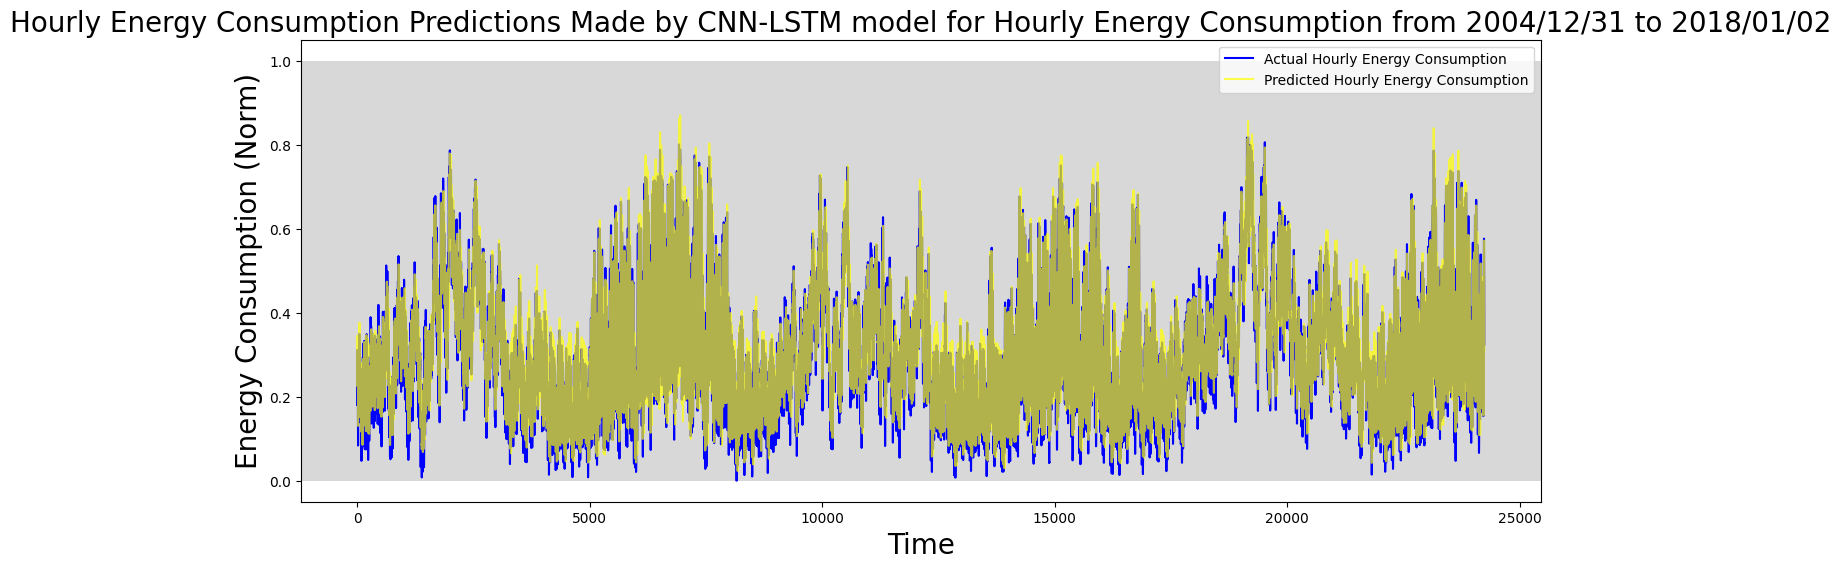

In [89]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(cnn_lstm_pred_test, alpha=0.7, color='yellow', \
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions Made by CNN-LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

### Training and Testing Data Comsbined.

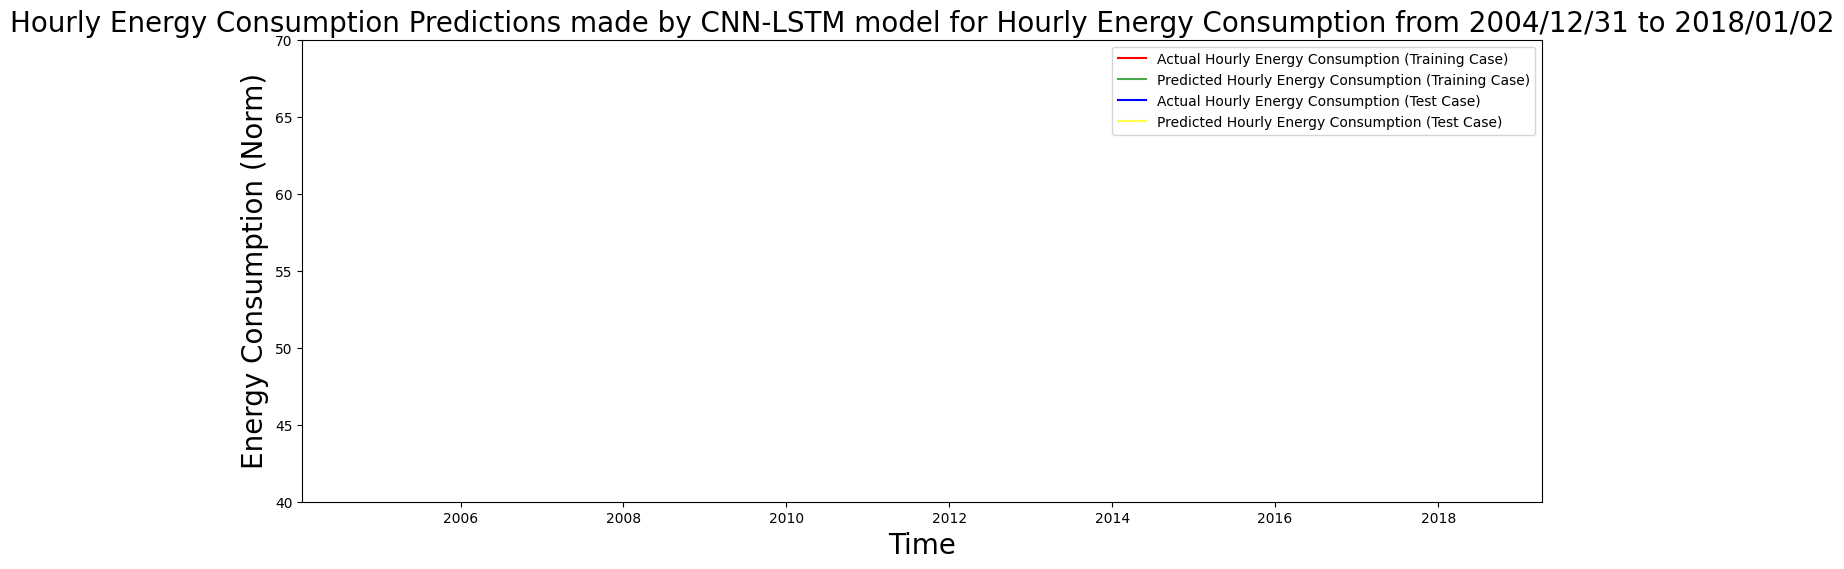

In [90]:
plt.figure(figsize=(16,6))
plt.plot(results_CNN_LSTM_train['Date'], results_CNN_LSTM_train['Actual'],
         color='red', label=f'Actual {feature} (Training Case)')
plt.plot(results_CNN_LSTM_train['Date'],  results_CNN_LSTM_train['Predicted'],
         alpha=0.7, color='green', label=f'Predicted {feature} (Training Case)')
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Actual'],
         color='blue', label=f'Actual {feature} (Test Case)')
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Predicted'],
         alpha=0.7, color='yellow', label=f'Predicted {feature} (Test Case)')
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by CNN-LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for CNN-LSTM.



In [91]:
results_CNN_LSTM = [results_CNN_LSTM_train, results_CNN_LSTM_test]
results_CNN_LSTM = pd.concat(results_CNN_LSTM)
display(results_CNN_LSTM)

,Date,Actual,Predicted
0,2004-10-01 01:00:00,13124.535187,13101.340820
1,2004-10-01 02:00:00,12948.731786,12806.806641
2,2004-10-01 03:00:00,12684.339953,12546.288086
3,2004-10-01 04:00:00,12368.443217,12297.082031
4,2004-10-01 05:00:00,12063.877560,12294.422852
...,...,...,...
24230,2018-08-02 20:00:00,13922.517811,14198.091797
24231,2018-08-02 21:00:00,13795.472384,13881.776367
24232,2018-08-02 22:00:00,13691.775847,13502.208984
24233,2018-08-02 23:00:00,13335.705287,13146.477539


## Plotting Residuals for Actual and Predicted Results for CNN-LSTM.

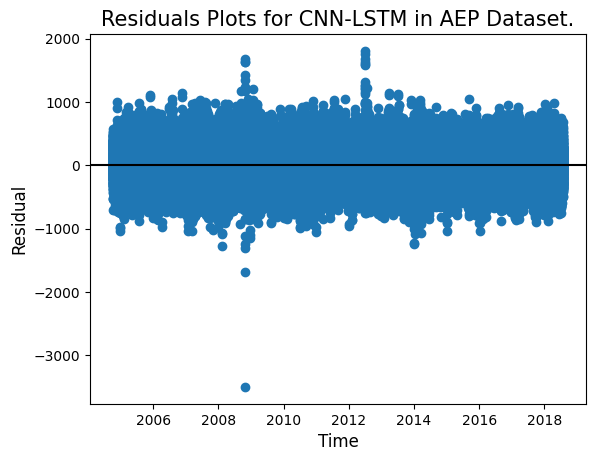

In [92]:
actual_arr_CNN_LSTM = np.array(results_CNN_LSTM['Actual'])
predicted_arr_CNN_LSTM = np.array(results_CNN_LSTM['Predicted'])
residuals_CNN_LSTM = predicted_arr_CNN_LSTM - actual_arr_CNN_LSTM
plt.scatter(results_CNN_LSTM['Date'], residuals_CNN_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residuals Plots for CNN-LSTM in AEP Dataset.".
          format(feature_field), fontsize=15)
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 12)
plt.ylabel("Residual", fontsize = 12)
plt.show()

From the residual plots for the CNN-LSTM model, it can be concluded that the CNN-LSTM model is a good fit.

## Energy Consumption

In [93]:
cnn_lstm_energy_results = measure_ann_energy(cnn_lstm_model, X_test)

Measuring inference time and estimating energy on CPU (for ANN)...
  CPU Inference Time: 1.6417 seconds
  Estimated CPU Energy: 131.3398 Joules (131339817.0471 µJ)

No GPU available. GPU measurements skipped.


# Ablation Studies

## LSTM Ablation Study

In [94]:
def run_ablation_study(model_builder_func, params, model_name):
    print(f"Running ablation for {model_name} with params: {params}")
    model = model_builder_func(**params)
    model.compile(optimizer='adam', loss=loss)
    # Suppress verbose output for fitting during ablation
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    # Parameter count
    param_count = model.count_params()

    # Inference time measurement
    # Warm-up run
    _ = model.predict(X_test[:1], verbose=0)
    start_time_inference = time.time()
    preds = model.predict(X_test, verbose=0)
    end_time_inference = time.time()
    inference_time = end_time_inference - start_time_inference

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # FLOPs calculation: This is a placeholder as direct FLOPs counting in Keras
    # without external libraries (like `keras-flops` or `tfmot`) is complex.
    # For a rough estimation or comparison, one might assume FLOPs are proportional
    # to parameter count, or use a general heuristic.
    # A common heuristic is ~2 FLOPs per parameter for a Dense layer (multiply-add).
    # This is highly model-dependent.
    conceptual_flops_per_param = 2 # This is a very rough estimate
    estimated_flops = param_count * conceptual_flops_per_param # Very rough proxy for computational operations

    # Energy proxy (conceptual: time spent * conceptual FLOPs)
    energy_proxy = inference_time * estimated_flops

    # Spike sparsity (optional, only relevant for SNNs)
    # This would require modifying LIFNeuronV3 to return spike counts or a custom callback.
    spike_sparsity = None # Not applicable for LSTM directly without specific SNN conversion

    return mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, spike_sparsity

def build_lstm_model_for_ablation(activation='tanh', units=32):
    model = Sequential()
    model.add(LSTM(units, activation=activation, return_sequences=True,
                    input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.5))
    model.add(LSTM(units, activation=activation, return_sequences=False))
    model.add(Dropout(0.5))
    model.add(Dense(1))
    return model

print("Starting LSTM Ablation Studies...")


# Ablation 1: Activation
results_lstm_activation = {}
for act_name in ['tanh', 'relu']:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_lstm_model_for_ablation, {'activation': act_name, 'units': unit}, f'LSTM (Activation: {act_name})'
    )
    results_lstm_activation[act_name] = {'MAE': mae, 'RMSE': rmse, 'Params': param_count,
                                           'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
                                           'Energy_Proxy': energy_proxy}
print("LSTM Activation Ablation Results:", results_lstm_activation)
tf.keras.backend.clear_session()
gc.collect()

# Ablation 2: Units
results_lstm_units = {}
for u in [32, 64]:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_lstm_model_for_ablation, {'units': u, 'activation': activation}, f'LSTM (Units: {u})'
    )
    results_lstm_units[f'{u}_units'] = {'MAE': mae, 'RMSE': rmse, 'Params': param_count,
                                           'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
                                           'Energy_Proxy': energy_proxy}
print("LSTM Units Ablation Results:", results_lstm_units)
tf.keras.backend.clear_session()
gc.collect()

Starting LSTM Ablation Studies...
Running ablation for LSTM (Activation: tanh) with params: {'activation': 'tanh', 'units': 32}
Running ablation for LSTM (Activation: relu) with params: {'activation': 'relu', 'units': 32}
LSTM Activation Ablation Results: {'tanh': {'MAE': 0.021316539356722355, 'RMSE': np.float64(0.02707049827612051), 'Params': 12705, 'Inference_Time': 5.157701253890991, 'Estimated_FLOPs': 25410, 'Energy_Proxy': 131057.18886137009}, 'relu': {'MAE': 0.03565260712577175, 'RMSE': np.float64(0.045604645840809824), 'Params': 12705, 'Inference_Time': 3.7977237701416016, 'Estimated_FLOPs': 25410, 'Energy_Proxy': 96500.1609992981}}
Running ablation for LSTM (Units: 32) with params: {'units': 32, 'activation': 'tanh'}
Running ablation for LSTM (Units: 64) with params: {'units': 64, 'activation': 'tanh'}
LSTM Units Ablation Results: {'32_units': {'MAE': 0.021502848596513198, 'RMSE': np.float64(0.027197351677116427), 'Params': 12705, 'Inference_Time': 3.9249179363250732, 'Estimate

0

## LIF SNN V3 Ablation Study

In [95]:
def build_lif_snn_v3_model_for_ablation(threshold=0.5, leak_rate=0.01,
                                        refractory_period=275, units=128,
                                        activation='tanh'):
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Reshape((-1, X_train.shape[1]),
                                    input_shape=(None, X_train.shape[1])),
            tf.keras.layers.TimeDistributed(tf.keras.layers.
                                            Dense(units, activation=activation)),
            LIFNeuronV3(threshold=threshold, leak_rate=leak_rate,
                        refractory_period=refractory_period),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Reshape((-1, units)),
            tf.keras.layers.GlobalAveragePooling1D(),
            tf.keras.layers.Dense(1),
        ]
    )
    return model

print("Starting LIF SNN V3 Ablation Studies...")

# Ablation 1: Threshold
results_lif_snn_v3_threshold = {}
for th in [0.5, 1.0]:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_lif_snn_v3_model_for_ablation,
        {'threshold': th, 'leak_rate': 0.01, 'refractory_period': 275,
         'units': 128, 'activation': 'tanh'},
        f'LIF SNN V3 (Threshold: {th})'
    )
    # Note: Spike sparsity is not directly calculable with the current
    # LIFNeuronV3 implementation. It would require modifying LIFNeuronV3 to
    # return spike counts or using a custom callback.
    results_lif_snn_v3_threshold[f'threshold_{th}'] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy, 'Spike_Sparsity': None}
print("LIF SNN V3 Threshold Ablation Results:", results_lif_snn_v3_threshold)

# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

# Ablation 2: Leak Rate
results_lif_snn_v3_leak_rate = {}
for lr in [0.01, 0.05]:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_lif_snn_v3_model_for_ablation,
        {'threshold': 0.5, 'leak_rate': lr, 'refractory_period': 275,
         'units': 128, 'activation': 'tanh'},
        f'LIF SNN V3 (Leak Rate: {lr})'
    )
    results_lif_snn_v3_leak_rate[f'leak_rate_{lr}'] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy, 'Spike_Sparsity': None}

print("LIF SNN V3 Leak Rate Ablation Results:", results_lif_snn_v3_leak_rate)

# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

# Ablation 3: Refractory Period
results_lif_snn_v3_refractory_period = {}
for rp in [100, 275]:
    mae, rmse, param_count, inference_time, \
     estimated_flops, energy_proxy, _ = run_ablation_study(
        build_lif_snn_v3_model_for_ablation,
        {'threshold': 0.5, 'leak_rate': 0.01, 'refractory_period': rp,
         'units': 128, 'activation': 'tanh'},
        f'LIF SNN V3 (Refractory Period: {rp})'
    )
    results_lif_snn_v3_refractory_period[f'refractory_{rp}'] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy, 'Spike_Sparsity': None
        }

print("LIF SNN V3 Refractory Period Ablation Results:",
      results_lif_snn_v3_refractory_period)

# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

# Ablation 4: Units in TimeDistributed Dense layer
results_lif_snn_v3_units = {}
for u in [64, 128]:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_lif_snn_v3_model_for_ablation,
        {'threshold': 0.5, 'leak_rate': 0.01, 'refractory_period': 275,
         'units': u, 'activation': 'tanh'},
        f'LIF SNN V3 (Units: {u})'
    )
    results_lif_snn_v3_units[f'{u}_units'] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy, 'Spike_Sparsity': None}

print("LIF SNN V3 Units Ablation Results:", results_lif_snn_v3_units)
# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

# Ablation 5: Activation of TimeDistributed Dense layer
results_lif_snn_v3_activation = {}
for act_name in ['tanh', 'relu']:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_lif_snn_v3_model_for_ablation,
        {'threshold': 0.5, 'leak_rate': 0.01, 'refractory_period': 275,
         'units': 128, 'activation': act_name},
        f'LIF SNN V3 (Activation: {act_name})'
    )
    results_lif_snn_v3_activation[act_name] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy, 'Spike_Sparsity': None}

print("LIF SNN V3 Activation Ablation Results:", results_lif_snn_v3_activation)
# Clear Session
tf.keras.backend.clear_session()
gc.collect()

Starting LIF SNN V3 Ablation Studies...
Running ablation for LIF SNN V3 (Threshold: 0.5) with params: {'threshold': 0.5, 'leak_rate': 0.01, 'refractory_period': 275, 'units': 128, 'activation': 'tanh'}
Running ablation for LIF SNN V3 (Threshold: 1.0) with params: {'threshold': 1.0, 'leak_rate': 0.01, 'refractory_period': 275, 'units': 128, 'activation': 'tanh'}
LIF SNN V3 Threshold Ablation Results: {'threshold_0.5': {'MAE': 0.10407898155209266, 'RMSE': np.float64(0.12906643379192193), 'Params': 2946, 'Inference_Time': 3.7131948471069336, 'Estimated_FLOPs': 5892, 'Energy_Proxy': 21878.144039154053, 'Spike_Sparsity': None}, 'threshold_1.0': {'MAE': 0.1361847102938803, 'RMSE': np.float64(0.16337113896907302), 'Params': 2946, 'Inference_Time': 4.618622541427612, 'Estimated_FLOPs': 5892, 'Energy_Proxy': 27212.92401409149, 'Spike_Sparsity': None}}
Running ablation for LIF SNN V3 (Leak Rate: 0.01) with params: {'threshold': 0.5, 'leak_rate': 0.01, 'refractory_period': 275, 'units': 128, 'act

0

## CNN-LSTM Ablation Study

In [96]:
def build_cnn_lstm_model_for_ablation(activation='tanh', units=32, filters=32, kernel_size=3):
    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation=activation,
                     input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation=activation))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(units, activation=activation, return_sequences=False))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    return model

print("Starting CNN-LSTM Ablation Studies...")

# Ablation 1: Activation
results_cnn_lstm_activation = {}
for act_name in ['tanh', 'relu']:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_cnn_lstm_model_for_ablation,
        {'activation': act_name, 'units': unit, 'filters': filter, 'kernel_size': kernel},
        f'CNN-LSTM (Activation: {act_name})'
    )
    results_cnn_lstm_activation[act_name] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy}

print("CNN-LSTM Activation Ablation Results:", results_cnn_lstm_activation)
# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

# Ablation 2: Units in LSTM layer
results_cnn_lstm_units = {}
for u in [32, 64]:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_cnn_lstm_model_for_ablation,
        {'units': u, 'activation': activation, 'filters': filter,
         'kernel_size': kernel},
        f'CNN-LSTM (Units: {u})'
    )
    results_cnn_lstm_units[f'{u}_units'] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy}
print("CNN-LSTM Units Ablation Results:", results_cnn_lstm_units)
# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

# Ablation 3: Filters in Conv1D layers
results_cnn_lstm_filters = {}
for f in [32, 64]:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_cnn_lstm_model_for_ablation,
        {'filters': f, 'activation': activation, 'units': unit,
         'kernel_size': kernel},
        f'CNN-LSTM (Filters: {f})'
    )
    results_cnn_lstm_filters[f'{f}_filters'] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy}
print("CNN-LSTM Filters Ablation Results:", results_cnn_lstm_filters)
# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

# Ablation 4: Kernel Size in Conv1D layers
results_cnn_lstm_kernel = {}
for k_size in [3, 5]:
    mae, rmse, param_count, inference_time, estimated_flops, energy_proxy, _ = run_ablation_study(
        build_cnn_lstm_model_for_ablation,
        {'kernel_size': k_size, 'activation': activation, 'units': unit,
         'filters': filter},
        f'CNN-LSTM (Kernel: {k_size})'
    )
    results_cnn_lstm_kernel[f'{k_size}_kernel'] = {
        'MAE': mae, 'RMSE': rmse, 'Params': param_count,
        'Inference_Time': inference_time, 'Estimated_FLOPs': estimated_flops,
        'Energy_Proxy': energy_proxy}
print("CNN-LSTM Kernel Size Ablation Results:", results_cnn_lstm_kernel)
# Clear Tensorflow Graph after run.
tf.keras.backend.clear_session()
gc.collect()

Starting CNN-LSTM Ablation Studies...
Running ablation for CNN-LSTM (Activation: tanh) with params: {'activation': 'tanh', 'units': 32, 'filters': 32, 'kernel_size': 3}
Running ablation for CNN-LSTM (Activation: relu) with params: {'activation': 'relu', 'units': 32, 'filters': 32, 'kernel_size': 3}
CNN-LSTM Activation Ablation Results: {'tanh': {'MAE': 0.038309872138180094, 'RMSE': np.float64(0.0478081878517379), 'Params': 11585, 'Inference_Time': 1.9311790466308594, 'Estimated_FLOPs': 23170, 'Energy_Proxy': 44745.41851043701}, 'relu': {'MAE': 0.03179546437551653, 'RMSE': np.float64(0.04039042094938113), 'Params': 11585, 'Inference_Time': 2.597593069076538, 'Estimated_FLOPs': 23170, 'Energy_Proxy': 60186.23141050339}}
Running ablation for CNN-LSTM (Units: 32) with params: {'units': 32, 'activation': 'tanh', 'filters': 32, 'kernel_size': 3}
Running ablation for CNN-LSTM (Units: 64) with params: {'units': 64, 'activation': 'tanh', 'filters': 32, 'kernel_size': 3}
CNN-LSTM Units Ablation 

0

# Compare Predictions

## Energy Efficiency Comparison

In [97]:
def plot_energy_results(all_results):
    print(f"all_results: {all_results}")
    cpu_times = [res['cpu_inference_time_s'] for res in all_results]
    estimated_cpu_energy_uJ = [res['estimated_cpu_energy_uJ']
                               for res in all_results]
    estimated_gpu_energy_uJ = [res['estimated_gpu_energy_uJ']
                               if res['estimated_gpu_energy_uJ'] is not None
                               else 0 for res in all_results]
    snn_spike_energy_uJ = [res['snn_spike_energy_uJ']
                           if res['snn_spike_energy_uJ'] is not None
                           else 0 for res in all_results]
    model_names = [res['model_name'] for res in all_results]

    x = np.arange(len(model_names))
    width = 0.2
    fig, ax1 = plt.subplots(figsize=(13, 6))

    # Plot estimated CPU Energy
    ax1.bar(x - width, estimated_cpu_energy_uJ, width,
            label='Estimated CPU Energy (µJ)', color='skyblue')
    # Plot estimated GPU Energy
    ax1.bar(x, estimated_gpu_energy_uJ, width,
            label='Estimated GPU Energy (µJ) (if available)', color='lightcoral')
    # Plot SNN Spike Energy
    ax1.bar(x + width, snn_spike_energy_uJ, width,
            label='Estimated SNN Spike Energy (µJ)', color='lightgreen')
    ax1.set_yscale('log')  # Set y-axis to logarithmic scale

    ax1.set_ylabel('Estimated Energy (µJ) (Log Scale)', fontsize=14,
                   fontweight='bold')
    ax1.set_xlabel('Model', fontsize=14, fontweight='bold')
    ax1.set_title('Estimated Energy Consumption per Model (Log Scale)' +
                  'for PeMS Dataset', fontsize=20, fontweight = 'bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45, ha="right", fontsize=12)
    ax1.tick_params(axis='y', labelsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

all_results: [{'model_name': 'LIF SNN V3 Model', 'cpu_inference_time_s': 20.992249965667725, 'estimated_cpu_energy_J': 1679.379997253418, 'estimated_cpu_energy_uJ': 1679379997.253418, 'gpu_inference_time_s': None, 'estimated_gpu_energy_J': None, 'estimated_gpu_energy_uJ': None, 'snn_spike_energy_uJ': 62041.6}, {'model_name': 'LSTM Model', 'cpu_inference_time_s': 3.5084238052368164, 'estimated_cpu_energy_J': 280.6739044189453, 'estimated_cpu_energy_uJ': 280673904.4189453, 'gpu_inference_time_s': None, 'estimated_gpu_energy_J': None, 'estimated_gpu_energy_uJ': None, 'snn_spike_energy_uJ': None}, {'model_name': 'sequential_2', 'cpu_inference_time_s': 1.6417477130889893, 'estimated_cpu_energy_J': 131.33981704711914, 'estimated_cpu_energy_uJ': 131339817.04711914, 'gpu_inference_time_s': None, 'estimated_gpu_energy_J': None, 'estimated_gpu_energy_uJ': None, 'snn_spike_energy_uJ': None}]


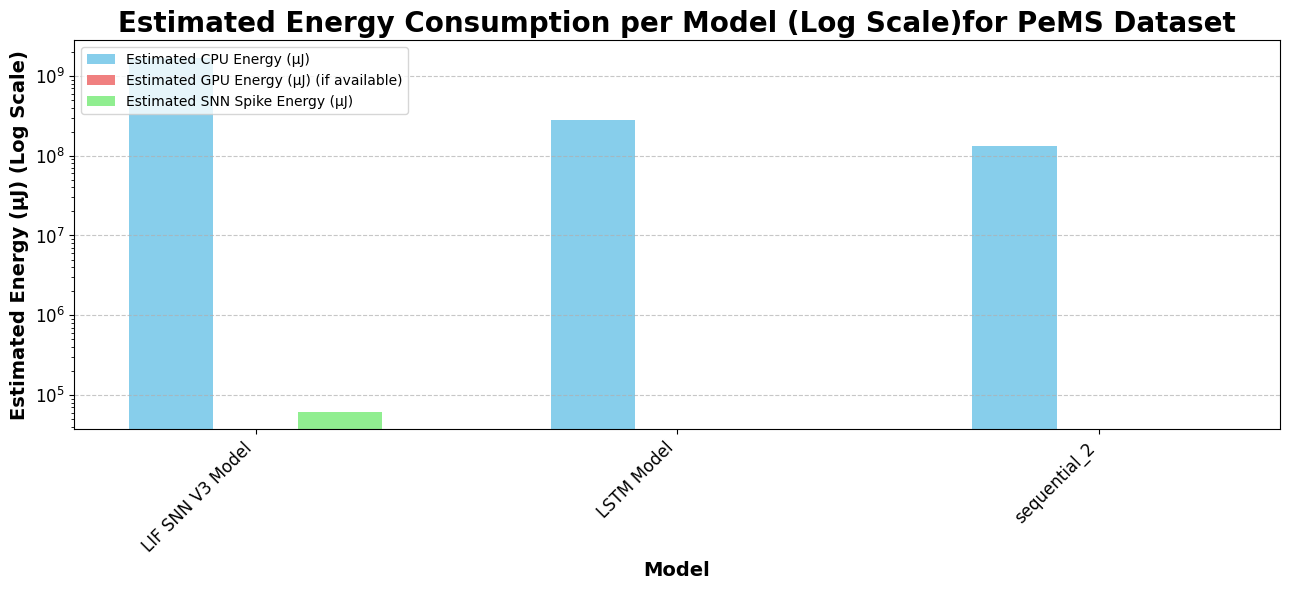

In [98]:
all_models_energy_results = [spiking_LIFv3_energy_results,
                             lstm_energy_results, cnn_lstm_energy_results]

plot_energy_results(all_models_energy_results)

## Applying Diebold-Mariano Test to Model Predictions

In [99]:
print("\n--- Diebold-Mariano Test Results ---")

models = {
    "LSTM": lstm_pred_test.flatten(),
    "LIF SNN V3": spiking_LIFv3_model_pred_test.flatten(),
    "CNN-LSTM": cnn_lstm_pred_test.flatten()
}

model_names = list(models.keys())

# Compare each model against every other model
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name1 = model_names[i]
        name2 = model_names[j]
        preds1 = models[name1]
        preds2 = models[name2]

        if len(y_test) != len(preds1) or len(y_test) != len(preds2):
            print(f"Skipping DM test for {name1} vs {name2} due to length mismatch.\n")
            continue

        try:
            dm_stat_mae, p_value_mae = diebold_mariano_mae(y_test, preds1, preds2)
            dm_stat_mse, p_value_mse = diebold_mariano_mse(y_test, preds1, preds2)

            print(f"Comparing {name1} vs {name2}:")
            print(f"DM Statistic (MAE loss): {dm_stat_mae:.4f}, p-value: {p_value_mae:.4f}")
            if p_value_mae < 0.05:
                print(f"(Significant difference: {name1} and {name2} have different predictive accuracy based on MAE loss)")
            else:
                print(f"(No significant difference: {name1} and {name2} have similar predictive accuracy based on MAE loss)")

            print(f"DM Statistic (MSE loss): {dm_stat_mse:.4f}, p-value: {p_value_mse:.4f}")
            if p_value_mse < 0.05:
                print(f"(Significant difference: {name1} and {name2} \n"
                "have different predictive accuracy based on MSE loss)")
            else:
                print(f"(No significant difference: {name1} and {name2} have similar predictive accuracy based on MSE loss)\n")

        except Exception as e:
            print(f"Error performing DM test for {name1} vs {name2}: {e}\n")



--- Diebold-Mariano Test Results ---
Comparing LSTM vs LIF SNN V3:
DM Statistic (MAE loss): -193.7363, p-value: 0.0000
(Significant difference: LSTM and LIF SNN V3 have different predictive accuracy based on MAE loss)
DM Statistic (MSE loss): -128.8155, p-value: 0.0000
(Significant difference: LSTM and LIF SNN V3 
have different predictive accuracy based on MSE loss)
Comparing LSTM vs CNN-LSTM:
DM Statistic (MAE loss): -84.4405, p-value: 0.0000
(Significant difference: LSTM and CNN-LSTM have different predictive accuracy based on MAE loss)
DM Statistic (MSE loss): -71.9997, p-value: 0.0000
(Significant difference: LSTM and CNN-LSTM 
have different predictive accuracy based on MSE loss)
Comparing LIF SNN V3 vs CNN-LSTM:
DM Statistic (MAE loss): 165.4216, p-value: 0.0000
(Significant difference: LIF SNN V3 and CNN-LSTM have different predictive accuracy based on MAE loss)
DM Statistic (MSE loss): 122.5769, p-value: 0.0000
(Significant difference: LIF SNN V3 and CNN-LSTM 
have different 

# Forecasting Future Data for all models

## Essential Functions.

In [100]:
# this section for unknown future.
future=20
#future=seq_len
# forecast_LSTM = [] # Removed as it's not used in the refactored forecast_data
# forecast_CNN_LSTM = [] # Removed as it's not used in the refactored forecast_data

# Initialize Xin with the last sequence from X_test for autoregressive forecasting
Xin = X_test[-1].reshape(1, seq_len, 1)
Xin

array([[[0.15377932],
        [0.16401887],
        [0.19858508],
        [0.25319598],
        [0.29446444],
        [0.32598982],
        [0.3554673 ],
        [0.39990071],
        [0.43874891],
        [0.48665756],
        [0.52662281],
        [0.55560382],
        [0.57372471],
        [0.5763932 ],
        [0.55734144],
        [0.52978776],
        [0.50217202],
        [0.47921062],
        [0.46046916],
        [0.39611518]]])

In [101]:
def insert_end_single_seq(current_sequence, new_input):
    """
    Shifts a single sequence (1, seq_len, 1) and inserts a new input at the end.
    """
    # Shift all elements one position to the left
    current_sequence[0, :-1, :] = current_sequence[0, 1:, :]
    # Insert the new input at the last position
    current_sequence[0, -1, :] = new_input
    return current_sequence

def forecast_data(initial_sequence, model_type, future_num, seq_len_param):
    """
    Generates future forecasts using a given model and initial sequence.

    Args:
        initial_sequence (np.array): The last sequence from the test set
                                     (shape: (1, seq_len, 1)).
        model_type (tf.keras.Model): The trained Keras model for prediction.
        future_num (int): The number of future steps to forecast.
        seq_len_param (int): The sequence length used for the model.

    Returns:
        pd.DataFrame: A DataFrame containing 'Date' and 'Forecasted' values.
    """
    forecast = []
    time_index = []
    current_sequence = np.copy(initial_sequence) # Work on a copy

    start_date = df_norm.index[-1] + timedelta(hours=1) # Start date for forecasting

    for i in range(future_num):
        # Predict the next step using the current sequence
        out = model_type.predict(current_sequence, verbose=0)[0, 0]
        forecast.append(out)

        # Generate the date for the current forecast
        current_date = start_date + timedelta(hours=i)
        time_index.append(current_date)

        # Update the sequence for the next prediction
        current_sequence = insert_end_single_seq(current_sequence, out)

    forcasted_output = np.asanyarray(forecast)
    forcasted_output = forcasted_output.reshape(-1, 1)
    forcasted_output = scaler.inverse_transform(forcasted_output)

    forecast_result = pd.DataFrame({"Date": time_index, "Forecasted": forcasted_output.flatten()})

    return forecast_result

In [102]:
# Plotting Predictions for VMT/VHT/Q for each model.
def plot_forecast(forecast_set, model_name, mode, min_val=None, max_val=None):
    plt.figure(figsize=(16,6))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title('{0} Forecast for {1} using {2}'.
              format(feature_field, mode, model_name), fontsize = 15)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    if min_val is not None and max_val is not None:
        plt.ylim([min_val, max_val])
    #plt.ylim([min, max]) # Original hardcoded line
    plt.xlabel('Time', fontsize = 15)
    #plt.ylabel(feature_field, fontsize = 15)
    plt.ylabel('Normalized {0} Scale'.format(feature_field), fontsize = 15)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.legend()
    plt.show()


In [103]:
# Plotting Predictions for VMT/VHT/Q for Training, Testing, and Future Data.
def plot_with_forecast(train_set, test_set, forecast_set, model_name, mode,
                       min_val=None, max_val=None):
    plt.figure(figsize=(16,6))
    plt.plot(train_set['Date'], train_set['Actual'], color='red',
             label='Actual {0} (Training Case)'.format(feature))
    plt.plot(train_set['Date'], train_set['Predicted'], alpha=0.7,
             color='green',
             label='Predicted {0} (Training Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Actual'], color='blue',
            label='Actual {0} (Test Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Predicted'], alpha=0.7, color='yellow',
             label='Predicted {0} (Test Case)'.format(feature))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title("{0} Predictions and Forecasts made by {1} model for {2}".
              format(feature_field, model_name, title_name), fontsize=15)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    if min_val is not None and max_val is not None:
        plt.ylim([min_val, max_val])
    #plt.ylim([min, max]) # Original hardcoded line
    plt.xlabel('Time', fontsize = 15)
    plt.ylabel('Normalized {0} Scale'.format(feature_field), fontsize = 15)
    plt.legend()
    plt.show()


## Forecasting Future Data for LSTM.

In [104]:
# Pass the global seq_len variable
forecast_result_lstm = forecast_data(Xin, lstm_model, future, seq_len)

In [105]:
forecast_result_lstm

,Date,Forecasted
0,2018-08-03 01:00:00,13174.649414
1,2018-08-03 02:00:00,12968.257812
2,2018-08-03 03:00:00,12810.980469
3,2018-08-03 04:00:00,12708.352539
4,2018-08-03 05:00:00,12658.807617
5,2018-08-03 06:00:00,12659.160156
6,2018-08-03 07:00:00,12703.645508
7,2018-08-03 08:00:00,12784.750977
8,2018-08-03 09:00:00,12893.372070
9,2018-08-03 10:00:00,13023.299805


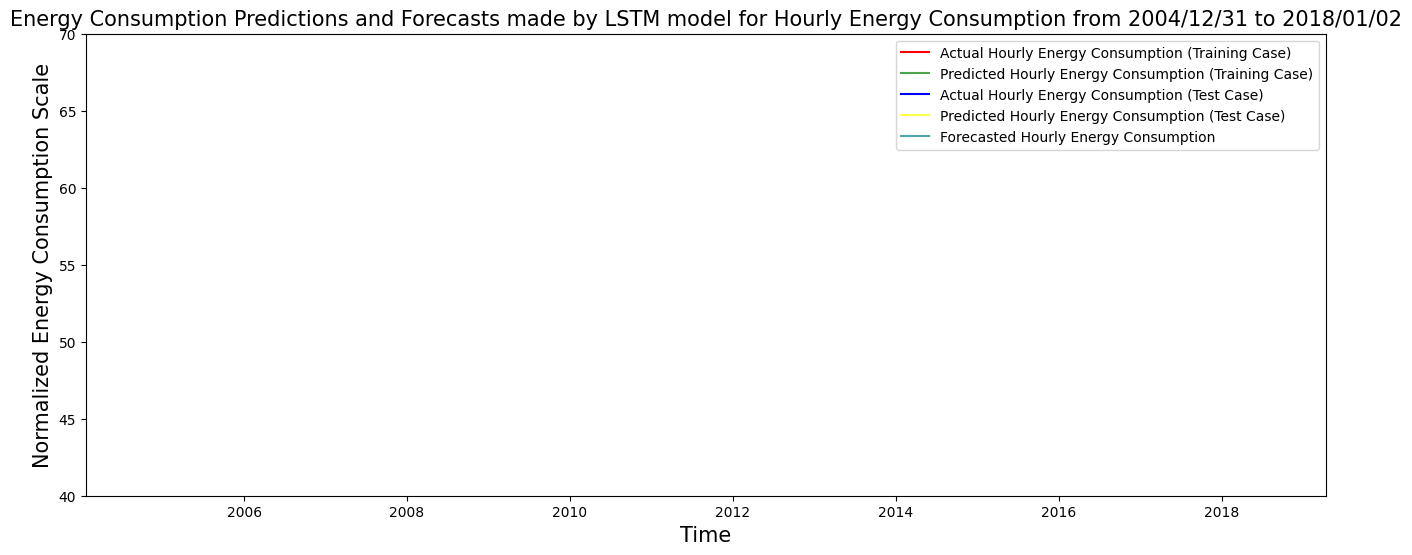

In [106]:
# Plot Forecast combined with Training and Testing Data.
plot_with_forecast(results_LSTM_train, results_LSTM_test, forecast_result_lstm,
                   'LSTM', title_name, min_val=40, max_val=70)

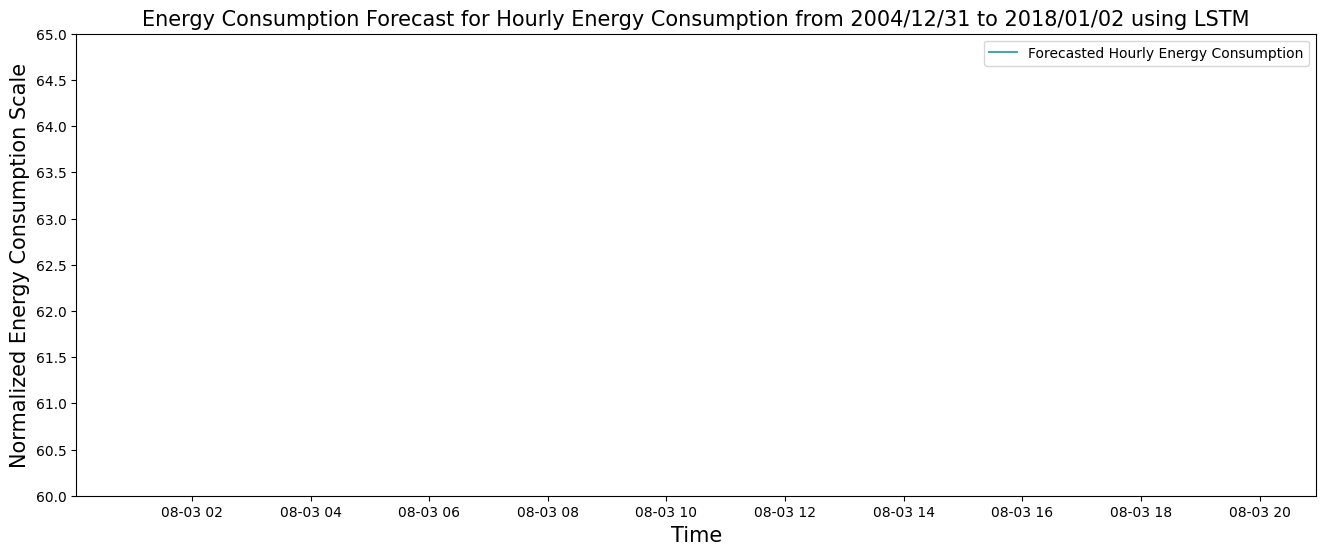

In [107]:
# Only Forecast Data for closer look.
plot_forecast(forecast_result_lstm, 'LSTM', title_name, min_val=60, max_val=65)

## Forecasting Future Data for CNN-LSTM.

In [108]:
# Pass the global seq_len variable
forecast_result_cnn_lstm = forecast_data(Xin, cnn_lstm_model, future, seq_len)

In [109]:
forecast_result_cnn_lstm

,Date,Forecasted
0,2018-08-03 01:00:00,12855.620117
1,2018-08-03 02:00:00,12889.618164
2,2018-08-03 03:00:00,12892.220703
3,2018-08-03 04:00:00,12471.250000
4,2018-08-03 05:00:00,12523.113281
5,2018-08-03 06:00:00,12483.898438
6,2018-08-03 07:00:00,12519.020508
7,2018-08-03 08:00:00,12550.592773
8,2018-08-03 09:00:00,12824.657227
9,2018-08-03 10:00:00,12849.219727


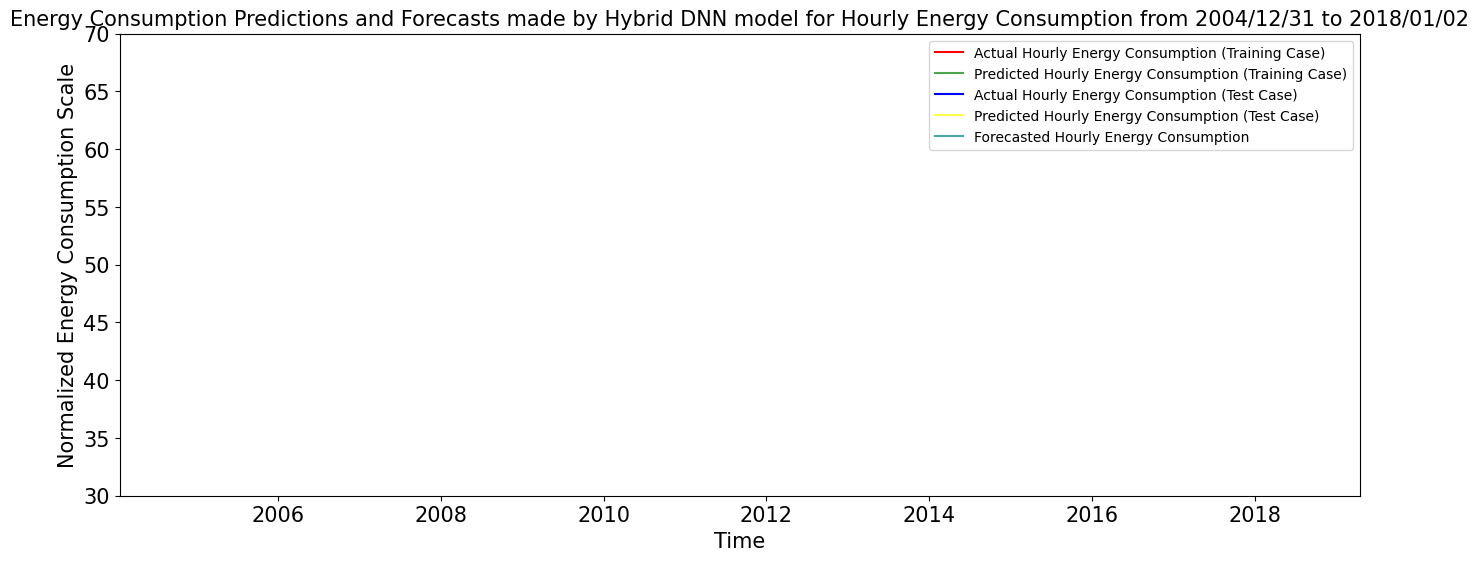

In [110]:
plot_with_forecast(results_CNN_LSTM_train, results_CNN_LSTM_test,
                   forecast_result_cnn_lstm, 'Hybrid DNN', title_name,
                   min_val=30, max_val=70)

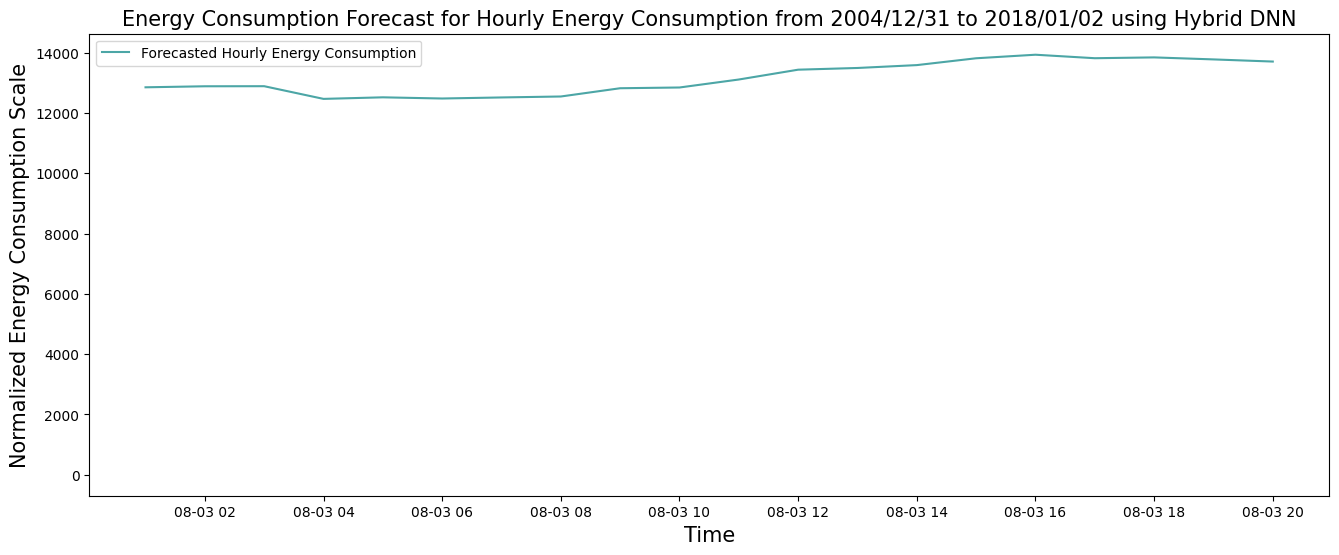

In [111]:
plot_forecast(forecast_result_cnn_lstm, 'Hybrid DNN', title_name)